# 2026-10-06 Corrected BPT line ratios by stage

Four selections: NSF, NSF+EW(Halpha)<3, TNSF and TNSF+EW(Halpha)<3.
Same sample, geometry, strict SNR_POSTFIT>25 and interval edges as the
dispersion notebook. Support remains **NSF-only**: >=50 usable pixels,
>=20 finite intrinsic-dispersion NSF pixels and >=25 distinct NSF gas BIN_IDs
per galaxy/interval; >=5 qualifying NSF galaxy products per stage/interval.
Intrinsic dispersion is retained only for the inherited classification and
support calculation. No dispersion results are plotted.

Plot log10 [O III]5007/Hbeta, [N II]6583/Halpha and
([S II]6716+6731)/Halpha versus stellar surface density and radius.
Use medians of individual corrected log10 ratios. Equal-galaxy points are
medians of within-galaxy ratio medians; pooled points are medians of all
supported pixel log ratios. This replaces the earlier ratio of mean line
intensities. Every whole-galaxy draw recomputes the corresponding median;
10,000 draws are shared across ratios, selections and intervals within a stage.

Ratio availability additionally requires the common six raw lines to pass
their FITS CUT_SN/NOISE detection thresholds, positive finite corrected fluxes,
and finite corrected Halpha surface intensity. This does not change the NSF
counting gate. Restricted selections have no independent count threshold;
actual ratio-data contributors are reported separately from NSF support.

Each ratio has one data-derived y-axis range shared across all selections and
both weightings. Spatial colors use the same range; saturation changes only
display. No additional density or radius cut. Source notebooks are unchanged.

**TNSF definition update (2026-10-08):** `NSF & (NII_BPT == 3) & np.isin(SII_BPT, [2, 3])`.
SII code 2 is LINER and code 3 is Seyfert; this joint requirement applies
to TNSF and all of its EW-restricted subsets in both BPT diagrams.
The existing SF, NSF, usable-disc footprint, strict SNR_POSTFIT cut,
support rules, and weighting conventions are retained.


In [1]:
from __future__ import annotations

import math
from pathlib import Path

import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from astropy.io import fits
from astropy.wcs import WCS
from IPython.display import display

PROJECT_ROOT = Path.cwd().resolve()
DATA_ROOT = PROJECT_ROOT / "v3tk_v7.6.8"
CATALOG_PATH = PROJECT_ROOT / "mauve_master_wiki_newclass.fits"
GEOMETRY_PATH = PROJECT_ROOT / "MAUVE_effective_radii.csv"

MASS_FILE_PATTERN = "{galid}_spatial_binning_maps_further.fits"
SFR_FILE_PATTERNS = (
    "{galid}_gas_bin_maps_further.fits",
    "{galid}_gas_BIN_maps_further.fits",
)
EW_FILE_PATTERNS = (
    "{galid}_proxy_EW_maps_further.fits",
    "{galid}_proxy_EW_maps.fits",
)
MASK_FILE_PATTERN = "{galid}_mask.fits"
SFH_FILE_PATTERN = "{galid}_sfh_maps.fits"

MASS_HDU = "LOGMASS_SURFACE_DENSITY"
BIN_HDU_MASS = "BINID"
BIN_HDU_GAS = "BIN_ID"
SFR_HDU = "LOGSFR_SURFACE_DENSITY_HII"
# All-spaxel ordinate only; SFR_HDU remains the original SF-selection map.
ALL_SFR_HDU = "LOGSFR_SURFACE_DENSITY"
EW_HDU = "PROXY_EWHA"
HALPHA_SIGMA_OBS_HDU = "HA6562_SIGMA"
HALPHA_SIGMA_CORR_HDU = "HA6562_SIGMA_CORR"
MASK_TABLE_HDU = "MASKFILE"
MASK_COLUMN = "MASK"
SFH_SNR_POSTFIT_HDU = "SNR_POSTFIT"

EW_HA_MIN = 6.0
HALPHA_SIGMA_MAX = 45.0
SFH_SNR_POSTFIT_MIN = 25.0
I_MAX_PRIMARY = 80.0
MIN_VALID_PIXELS_PER_BIN = 50
MIN_SF_PIXELS_PER_BIN = 20
WCS_TOLERANCE_ARCSEC = 0.05

SIGMA_BIN_WIDTH = 0.25
RADIUS_BIN_WIDTH = 0.25
FIXED_RELIABLE_RANGES = {"log_sigma_star": (7.0, 9.5), "radius_re": (0.0, 2.5)}
MASS_CONTOUR_LEVEL = 7.5

mpl.rcParams.update({
    "figure.dpi": 120,
    "savefig.dpi": 300,
    "font.size": 11,
    "axes.grid": False,
})


BALMER_LINES = ("HB4861", "HA6562")
REASON_LABELS = (
    "BPT: stable non-HII", "BPT: weak/ambiguous/unavailable", "HII SFR unavailable",
    "EW unavailable", "EW <= 6", "Dispersion unavailable", "Dispersion >= 45",
)
N_BOOTSTRAP = 10_000
RANDOM_SEED = 42
DIAGNOSTIC_MIN_PIXELS_PER_BIN = 20
MIN_DISTINCT_GAS_BINS_PER_BIN = 25
MIN_GALAXIES_PER_STAGE_BIN = 5
EW_HA_MAX_RESTRICTED = 3.0
CATEGORY_ORDER = ("NSF", "NSF + EW(Halpha)<3", "TNSF", "TNSF + EW(Halpha)<3")
VARIABLES = ("log_sigma_star", "radius_re")
BRANCH_LABELS = {"equal": "Equal-galaxy median", "pooled": "Pooled-spaxel median"}
STAGE_COLORS = {"pre-peak": "#2166ac", "close-to-peak": "#1a9850", "post-peak": "#d73027"}
print(f"Project root: {PROJECT_ROOT}")
print("Scope: corrected BPT line ratios; four selections; shared NSF support")

SOURCE_NOTEBOOK_SHA256 = {'20261006_check_emission_line_fading_BPT_ratios_Halpha_sigma_TNSF_by_stage.ipynb': '71844cfecef705d941152fd29e6e2d928d2e0c10de97ba077fc2d33f983cb2e9', '20261006_check_emission_line_fading_BPT_ratios_Halpha_sigma_NSF_by_stage.ipynb': '15499877f0e025c50370688f842ca58a976b4d42b4879534ef0f8e224a44bc10'}

BPT_RAW_LINES = ("HA6562","HB4861","OIII5006","NII6583","SII6716","SII6730")
LINE_ORDER = ("HA6562","HB4861","OIII5006","NII6583","SII_SUM")
RATIO_ORDER = ("OIII_Hb","NII_Ha","SII_Ha")
RATIO_INDICES = {"OIII_Hb":(2,1),"NII_Ha":(3,0),"SII_Ha":(4,0)}
RATIO_LABELS = {
    "OIII_Hb":r"$\log_{10}([\mathrm{O\,III}]5007/\mathrm{H}\beta)$",
    "NII_Ha":r"$\log_{10}([\mathrm{N\,II}]6583/\mathrm{H}\alpha)$",
    "SII_Ha":r"$\log_{10}(([\mathrm{S\,II}]6716+6731)/\mathrm{H}\alpha)$",
}


Project root: /Users/Igniz/Desktop/ICRAR/further
Scope: corrected BPT line ratios; four selections; shared NSF support


## Inherited masks, geometry and live sample

In [2]:
def normalise_stage_label(value) -> str:
    mapping = {
        1: "pre-peak", 1.0: "pre-peak", "1": "pre-peak",
        2: "close-to-peak", 2.0: "close-to-peak", "2": "close-to-peak",
        3: "post-peak", 3.0: "post-peak", "3": "post-peak",
        "prepeak": "pre-peak", "pre-peak": "pre-peak",
        "close-to-peak": "close-to-peak", "closetopeak": "close-to-peak",
        "near-peak": "close-to-peak", "postpeak": "post-peak", "post-peak": "post-peak",
    }
    key = value if isinstance(value, (int, float)) else str(value).strip().lower().replace(" ", "")
    if key not in mapping:
        raise ValueError(f"Unrecognised RPS/infall stage label: {value!r}")
    return mapping[key]

def first_existing(paths):
    for path in paths:
        for candidate in (path, Path(str(path) + ".gz")):
            if candidate.exists():
                return candidate
    return None

def load_fits_map(path: Path, hdu_name: str, *, return_header: bool = False):
    with fits.open(path, memmap=True) as hdul:
        names = {hdu.name.upper() for hdu in hdul}
        if hdu_name.upper() not in names:
            raise KeyError(f"{path}: missing HDU {hdu_name}; available={sorted(names)}")
        hdu = hdul[hdu_name]
        data = np.asarray(hdu.data, dtype=float).copy()
        header = hdu.header.copy()
    return (data, header) if return_header else data

def load_ngist_mask(path: Path, shape):
    with fits.open(path, memmap=True) as hdul:
        if MASK_TABLE_HDU not in hdul:
            raise KeyError(f"{path}: missing table HDU {MASK_TABLE_HDU}")
        table = hdul[MASK_TABLE_HDU].data
        if MASK_COLUMN not in table.names:
            raise KeyError(f"{path}: missing mask column {MASK_COLUMN}; available={table.names}")
        flat = np.asarray(table[MASK_COLUMN], dtype=int)
    if flat.size != int(np.prod(shape)):
        raise ValueError(f"{path}: mask length {flat.size} cannot reshape to {shape}")
    return flat.reshape(shape)

def celestial_wcs_separation_arcsec(header_a, header_b, shape):
    wa, wb = WCS(header_a).celestial, WCS(header_b).celestial
    if not wa.has_celestial or not wb.has_celestial:
        return np.inf
    ny, nx = shape
    x = np.array([0, nx - 1, 0, nx - 1, (nx - 1) / 2])
    y = np.array([0, 0, ny - 1, ny - 1, (ny - 1) / 2])
    raa, deca = wa.pixel_to_world_values(x, y)
    rab, decb = wb.pixel_to_world_values(x, y)
    cosd = np.cos(np.deg2rad((deca + decb) / 2))
    return float(np.nanmax(np.hypot((raa - rab) * cosd, deca - decb)) * 3600.0)

def tangent_offsets_arcsec(ra_deg, dec_deg, ra0_deg, dec0_deg):
    ra, dec = np.deg2rad(ra_deg), np.deg2rad(dec_deg)
    ra0, dec0 = np.deg2rad(float(ra0_deg)), np.deg2rad(float(dec0_deg))
    dra = (ra - ra0 + np.pi) % (2 * np.pi) - np.pi
    cosc = np.sin(dec0) * np.sin(dec) + np.cos(dec0) * np.cos(dec) * np.cos(dra)
    with np.errstate(divide="ignore", invalid="ignore"):
        east = np.cos(dec) * np.sin(dra) / cosc
        north = (np.cos(dec0) * np.sin(dec) - np.sin(dec0) * np.cos(dec) * np.cos(dra)) / cosc
    return east * 206264.806247, north * 206264.806247

def calculate_deprojected_radius(shape, header, component_rows: pd.DataFrame):
    # Minimum elliptical R/Re over the physical components of one product.
    wcs = WCS(header).celestial
    if not wcs.has_celestial:
        raise ValueError("No celestial WCS available for radius calculation")
    yy, xx = np.indices(shape, dtype=float)
    ra, dec = wcs.pixel_to_world_values(xx, yy)
    radius = np.full(shape, np.inf, dtype=float)
    for _, component in component_rows.iterrows():
        east, north = tangent_offsets_arcsec(
            ra, dec, component.center_ra_deg, component.center_dec_deg
        )
        pa = np.deg2rad(float(component.pa_deg_east_of_north))
        major = east * np.sin(pa) + north * np.cos(pa)
        minor = east * np.cos(pa) - north * np.sin(pa)
        component_radius = np.sqrt(
            (major / float(component.a_re_arcsec)) ** 2
            + (minor / float(component.b_re_arcsec)) ** 2
        )
        radius = np.minimum(radius, component_radius)
    radius[~np.isfinite(radius)] = np.nan
    return radius

def intrinsic_sigma_from_maps(sigma_obs, sigma_corr):
    sigma2 = np.asarray(sigma_obs, dtype=float) ** 2 - np.asarray(sigma_corr, dtype=float) ** 2
    result = np.full(sigma2.shape, np.nan, dtype=float)
    valid = np.isfinite(sigma2) & (sigma2 > 0)
    result[valid] = np.sqrt(sigma2[valid])
    return result

def load_galaxy_maps(row, geometry):
    mass, mass_header = load_fits_map(row.mass_path, MASS_HDU, return_header=True)
    mass_bin = load_fits_map(row.mass_path, BIN_HDU_MASS)
    gas_bin, gas_header = load_fits_map(row.sfr_path, BIN_HDU_GAS, return_header=True)
    sfr = load_fits_map(row.sfr_path, SFR_HDU)
    ew_ha = load_fits_map(row.ew_path, EW_HDU)
    sigma_obs = load_fits_map(row.sfr_path, HALPHA_SIGMA_OBS_HDU)
    sigma_corr = load_fits_map(row.sfr_path, HALPHA_SIGMA_CORR_HDU)
    snr_postfit = load_fits_map(row.sfh_path, SFH_SNR_POSTFIT_HDU)
    shapes = {a.shape for a in (
        mass, mass_bin, gas_bin, sfr, ew_ha, sigma_obs, sigma_corr, snr_postfit
    )}
    if len(shapes) != 1:
        raise ValueError(f"{row.GALID}: map shape mismatch {sorted(shapes)}")
    wcs_sep = celestial_wcs_separation_arcsec(mass_header, gas_header, mass.shape)
    if not np.isfinite(wcs_sep) or wcs_sep > WCS_TOLERANCE_ARCSEC:
        raise ValueError(f"{row.GALID}: mass/gas WCS mismatch {wcs_sep:.4f} arcsec")
    ngist_mask = load_ngist_mask(row.mask_path, mass.shape)
    components = geometry.loc[geometry.notebook_product_id.eq(row.GALID)].copy()
    radius_re = calculate_deprojected_radius(mass.shape, mass_header, components)
    sigma_intrinsic = intrinsic_sigma_from_maps(sigma_obs, sigma_corr)
    valid = (
        np.isfinite(mass) & np.isfinite(gas_bin) & (ngist_mask == 0) & np.isfinite(radius_re)
    )
    sf = (
        valid & np.isfinite(sfr) & np.isfinite(ew_ha) & (ew_ha > EW_HA_MIN)
        & np.isfinite(sigma_intrinsic) & (sigma_intrinsic < HALPHA_SIGMA_MAX)
    )
    maps = {
        "log_sigma_star": mass,
        "log_sigma_sfr": sfr,
        "radius_re": radius_re,
        "snr_postfit": snr_postfit,
        "sigma_intrinsic": sigma_intrinsic,
        "gas_bin_id": gas_bin,
        "ew_ha": ew_ha,
        "valid_disc_mask": valid,
        "sf_mask": sf,
        "mass_header": mass_header,
        "wcs_separation_arcsec": wcs_sep,
    }
    return add_detection_categories(maps, row, ew_ha, sigma_intrinsic)

def add_detection_categories(maps, row, ew_ha, sigma_intrinsic):
    """Use Balmer-only ND and preserve the original SF selection exactly."""
    valid, sf = maps["valid_disc_mask"], maps["sf_mask"]
    detected = {}
    invalid_any = np.zeros(valid.shape, dtype=bool)
    with fits.open(row.sfr_path, memmap=True) as hdul:
        header = hdul[0].header
        sn_cut, flux_floor = float(header["CUT_SN"]), float(header["NOISE"])
        if not (np.isfinite(sn_cut) and sn_cut > 0 and np.isfinite(flux_floor) and flux_floor > 0):
            raise ValueError(f"{row.GALID}: invalid detection thresholds")
        if str(header["BPTMODE"]).strip().lower() != "both":
            raise ValueError(f"{row.GALID}: expected the original both-BPT selection")
        for line in BALMER_LINES:
            flux = np.asarray(hdul[line + "_FLUX"].data, dtype=float)
            error = np.asarray(hdul[line + "_FLUX_ERR"].data, dtype=float)
            if flux.shape != valid.shape or error.shape != valid.shape:
                raise ValueError(f"{row.GALID}: {line} shape mismatch")
            measurable = np.isfinite(flux) & np.isfinite(error) & (error > 0)
            invalid_any |= ~measurable
            with np.errstate(divide="ignore", invalid="ignore"):
                detected[line] = measurable & (flux / error >= sn_cut) & (flux >= flux_floor)
        # Do not use the old NII_HA_BPT / SII_HA_BPT ratio HDUs as class maps.
        nii = np.asarray(hdul["NII_BPT"].data).copy()
        sii = np.asarray(hdul["SII_BPT"].data).copy()
        for name, arr in (("NII_BPT", nii), ("SII_BPT", sii)):
            if arr.shape != valid.shape or not np.isin(arr[valid], [-1, 0, 1, 2, 3]).all():
                raise ValueError(f"{row.GALID}: invalid {name} class map")
        provenance = {key: header.get(key, "not recorded")
                      for key in ("CUT_SN", "NOISE", "BPTMODE", "BPTLIMIT", "DUSTLAW")}
    balmer_detected = detected["HA6562"] & detected["HB4861"]
    if np.any(sf & ~balmer_detected):
        raise AssertionError(f"{row.GALID}: original SF includes a Balmer non-detection")
    nd = valid & ~balmer_detected
    nsf = valid & balmer_detected & ~sf
    # Exclusive bookkeeping, in this order: HII gate -> EW gate -> sigma gate.
    # This is a first-failed-gate decomposition, not a unique physical cause.
    has_sfr = np.isfinite(maps["log_sigma_sfr"])
    stable_non_hii = np.isin(nii, [2, 3]) | np.isin(sii, [2, 3])
    both_hii = (nii == 1) & (sii == 1)
    conditions = (
        ~has_sfr & stable_non_hii,
        ~has_sfr & ~both_hii,
        ~has_sfr,
        ~np.isfinite(ew_ha),
        ew_ha <= EW_HA_MIN,
        ~np.isfinite(sigma_intrinsic),
        sigma_intrinsic >= HALPHA_SIGMA_MAX,
    )
    remainder = nsf.copy()
    reasons = {}
    for label, condition in zip(REASON_LABELS, conditions):
        reasons[label] = remainder & condition
        remainder &= ~condition
    if remainder.any():
        raise AssertionError(f"{row.GALID}: unexplained detected non-SF pixels")
    category_sum = sf.astype(np.int8) + nd + nsf
    assert np.array_equal(category_sum, valid.astype(np.int8))
    assert np.array_equal(np.sum(list(reasons.values()), axis=0), nsf.astype(int))
    tnsf = nsf & (nii == 3) & np.isin(sii, [2, 3])
    assert not np.any(tnsf & ~nsf)
    assert np.all(nii[tnsf] == 3)
    assert np.isin(sii[tnsf], [2, 3]).all()
    maps.update({
        "tnsf_mask": tnsf, "nii_bpt_class": nii, "sii_bpt_class": sii,
        "nd_mask": nd, "nsf_mask": nsf, "balmer_detected_mask": balmer_detected,
        "line_detected": detected, "nsf_reasons": reasons,
        "nd_invalid_mask": nd & invalid_any,
        "nd_measured_below_cut_mask": nd & ~invalid_any,
        "detection_provenance": provenance,
    })
    return maps

In [3]:
def read_master_catalogue(path):
    with fits.open(path) as hdul:
        table = hdul[1].data
        frame = pd.DataFrame({
            "galaxy": [str(value).strip() for value in table["Galaxy"]],
            "logMstar": np.asarray(table["logMstar"], dtype=float),
            "stage_code": np.asarray(table["class"], dtype=float),
        })
    frame["stage"] = frame.stage_code.map(normalise_stage_label)
    return frame


def discover_products(data_root):
    rows = []
    for folder in sorted(path for path in data_root.iterdir()
                         if path.is_dir() and not path.name.endswith("_logs")):
        galid = folder.name
        rows.append({
            "GALID": galid,
            "mass_path": folder / MASS_FILE_PATTERN.format(galid=galid),
            "sfr_path": first_existing([
                folder / pattern.format(galid=galid) for pattern in SFR_FILE_PATTERNS
            ]),
            "ew_path": first_existing([
                folder / pattern.format(galid=galid) for pattern in EW_FILE_PATTERNS
            ]),
            "mask_path": folder / MASK_FILE_PATTERN.format(galid=galid),
            "sfh_path": first_existing([
                folder / SFH_FILE_PATTERN.format(galid=galid)
            ]),
        })
    return pd.DataFrame(rows)


STAGE_ORDER = ("pre-peak", "close-to-peak", "post-peak")
PANEL_ORDER = STAGE_ORDER + ("all stages",)
STAGE_LABELS = {
    "pre-peak": "Pre-peak",
    "close-to-peak": "Close-to-peak",
    "post-peak": "Post-peak",
    "all stages": "All stages",
}

master = read_master_catalogue(CATALOG_PATH)
geometry = pd.read_csv(GEOMETRY_PATH)
required_geometry = {
    "galaxy", "notebook_product_id", "mauve_infall_stage", "center_ra_deg",
    "center_dec_deg", "inclination_deg", "pa_deg_east_of_north",
    "a_re_arcsec", "b_re_arcsec",
}
missing_geometry = required_geometry - set(geometry.columns)
if missing_geometry:
    raise KeyError(f"{GEOMETRY_PATH}: missing columns {sorted(missing_geometry)}")

geometry = geometry.merge(
    master[["galaxy", "logMstar", "stage"]], on="galaxy", how="left",
    validate="one_to_one",
)
geometry["stage_from_geometry"] = geometry.mauve_infall_stage.map(normalise_stage_label)
if not geometry.stage.eq(geometry.stage_from_geometry).all():
    raise RuntimeError("Stage disagreement between the master and effective-radius catalogues")

product_meta = []
for galid, group in geometry.groupby("notebook_product_id", sort=False):
    if group.stage.nunique() != 1:
        raise RuntimeError(f"{galid}: physical components have inconsistent stages")
    product_meta.append({
        "GALID": galid,
        "components": ",".join(group.galaxy),
        "stage": group.stage.iloc[0],
        "inclination": float(group.inclination_deg.max()),
    })

inventory = pd.DataFrame(product_meta).merge(
    discover_products(DATA_ROOT), on="GALID", how="left", validate="one_to_one"
)
candidates = inventory.loc[
    inventory.stage.isin(STAGE_ORDER) & inventory.inclination.lt(I_MAX_PRIMARY)
].sort_values(["stage", "GALID"]).reset_index(drop=True)

# This first pass performs full live QC and records only range/count summaries.
# Maps are not cached so the combined notebook does not retain all galaxies in memory.
qc_rows = []
for row in candidates.itertuples(index=False):
    flags = []
    for label, path in (("mass", row.mass_path), ("sfr", row.sfr_path),
                        ("ew", row.ew_path), ("mask", row.mask_path),
                        ("sfh", row.sfh_path)):
        if not isinstance(path, Path) or not path.exists():
            flags.append(f"missing_{label}_product")
    maps = None
    if not flags:
        try:
            maps = load_galaxy_maps(row, geometry)
            valid = maps["valid_disc_mask"]
            if np.any(maps["sf_mask"] & ~valid):
                flags.append("sf_not_subset_of_valid")
        except Exception as exc:
            flags.append(f"load_error:{type(exc).__name__}:{exc}")
    if maps is not None and not flags:
        valid = maps["valid_disc_mask"]
        category_total = (
            maps["sf_mask"].astype(np.int8)
            + maps["nd_mask"].astype(np.int8)
            + maps["nsf_mask"].astype(np.int8)
        )
        if not np.array_equal(category_total, valid.astype(np.int8)):
            flags.append("category_accounting_failure")
    qc_rows.append({
        "GALID": row.GALID,
        "components": row.components,
        "stage": row.stage,
        "inclination_deg": row.inclination,
        "N_valid": int(valid.sum()) if maps is not None and not flags else 0,
        "N_NSF": int(maps["nsf_mask"].sum()) if maps is not None and not flags else 0,
        "sigma_min": float(np.nanmin(maps["log_sigma_star"][valid]))
                     if maps is not None and not flags else np.nan,
        "sigma_max": float(np.nanmax(maps["log_sigma_star"][valid]))
                     if maps is not None and not flags else np.nan,
        "radius_min": float(np.nanmin(maps["radius_re"][valid]))
                      if maps is not None and not flags else np.nan,
        "radius_max": float(np.nanmax(maps["radius_re"][valid]))
                      if maps is not None and not flags else np.nan,
        "wcs_separation_arcsec": maps["wcs_separation_arcsec"]
                                if maps is not None and not flags else np.nan,
        "QC_flag": ";".join(flags) if flags else "OK",
    })
    del maps

SAMPLE_QC = pd.DataFrame(qc_rows)
passed_ids = set(SAMPLE_QC.loc[SAMPLE_QC.QC_flag.eq("OK"), "GALID"])
sample = candidates.loc[candidates.GALID.isin(passed_ids)].copy()

display(SAMPLE_QC)
display(SAMPLE_QC.groupby(["stage", "QC_flag"], observed=True).size().rename("N_galaxies"))
for stage in STAGE_ORDER:
    n_pass = int(sample.stage.eq(stage).sum())
    n_candidate = int(candidates.stage.eq(stage).sum())
    print(f"{STAGE_LABELS[stage]}: {n_pass}/{n_candidate} products pass QC")
    if n_pass == 0:
        raise RuntimeError(f"No {stage} galaxies passed the live product QC")
print(f"Total passing products: {len(sample)}/{len(candidates)}")

,GALID,components,stage,inclination_deg,N_valid,N_NSF,sigma_min,sigma_max,radius_min,radius_max,wcs_separation_arcsec,QC_flag
0,NGC4298,NGC4298,close-to-peak,52.0,498540,44039,6.476232,9.372817,0.002597,2.927309,0.0,OK
1,NGC4424,NGC4424,close-to-peak,61.0,172561,38973,7.113861,9.027295,0.002721,2.533259,0.0,OK
2,NGC4501,NGC4501,close-to-peak,65.0,664236,263460,6.926827,10.916401,0.002436,2.862775,0.0,OK
3,NGC4654,NGC4654,close-to-peak,61.0,659231,124396,6.043689,9.750619,0.000637,2.836630,0.0,OK
4,NGC4694,NGC4694,close-to-peak,62.0,94538,28161,6.934593,9.479634,0.004544,3.796772,0.0,OK
5,IC3392,IC3392,post-peak,68.0,94575,9195,6.969276,9.253759,0.004326,3.084733,0.0,OK
6,NGC4064,NGC4064,post-peak,70.0,179882,34479,6.811374,9.428892,0.002945,1.939061,0.0,OK
7,NGC4293,NGC4293,post-peak,67.0,261523,63907,7.243091,10.336573,0.001645,1.842599,0.0,OK
8,NGC4380,NGC4380,post-peak,61.0,502065,53815,6.694095,10.141226,0.001755,2.963534,0.0,OK
9,NGC4394,NGC4394,post-peak,32.0,180654,46546,7.352380,10.783341,0.001999,1.488715,0.0,OK


stage          QC_flag                                                                                             
close-to-peak  OK                                                                                                       5
post-peak      OK                                                                                                      13
               missing_mass_product;missing_sfr_product;missing_ew_product;missing_mask_product;missing_sfh_product     3
pre-peak       OK                                                                                                       8
Name: N_galaxies, dtype: int64

Pre-peak: 8/8 products pass QC
Close-to-peak: 5/5 products pass QC
Post-peak: 13/16 products pass QC
Total passing products: 26/29


## Shared NSF support (identical to the dispersion notebook)

In [4]:
def complete_common_edges(minimum, maximum, width, *, lower_limit=None):
    minimum, maximum, width = float(minimum), float(maximum), float(width)
    start = float(lower_limit) if lower_limit is not None else np.floor(minimum / width) * width
    stop = (np.floor(maximum / width) + 1.0) * width
    edges = np.arange(start, stop + 0.5 * width, width)
    if not (edges[0] <= minimum and edges[-1] > maximum):
        raise AssertionError("Common edges do not enclose the live valid range")
    return edges


passing_qc = SAMPLE_QC.loc[SAMPLE_QC.QC_flag.eq("OK")]
COMMON_EDGES = {
    "log_sigma_star": complete_common_edges(
        passing_qc.sigma_min.min(), passing_qc.sigma_max.max(), SIGMA_BIN_WIDTH
    ),
    "radius_re": complete_common_edges(
        passing_qc.radius_min.min(), passing_qc.radius_max.max(),
        RADIUS_BIN_WIDTH, lower_limit=0.0,
    ),
}
VARIABLE_LABELS = {
    "log_sigma_star": r"$\log_{10}(\Sigma_\star/[M_\odot\,\mathrm{kpc}^{-2}])$",
    "radius_re": r"$R/R_e$",
}

def nsf_profile_supported(frame):
    return (frame.eligible_usable
            & frame.N_sigma_Ha.ge(DIAGNOSTIC_MIN_PIXELS_PER_BIN)
            & frame.N_unique_gas_bins.ge(MIN_DISTINCT_GAS_BINS_PER_BIN))


dispersion_rows, selection_rows = [], []
all_masks_exact = True
for row in sample.itertuples(index=False):
    maps = load_galaxy_maps(row, geometry)
    keep = maps["valid_disc_mask"] & np.isfinite(maps["snr_postfit"]) & (maps["snr_postfit"] > SFH_SNR_POSTFIT_MIN)
    sigma = maps["sigma_intrinsic"]
    ew = maps["ew_ha"]
    nsf = maps["nsf_mask"] & keep
    tnsf = nsf & (maps["nii_bpt_class"] == 3) & np.isin(maps["sii_bpt_class"], [2, 3])
    ew_lt3 = np.isfinite(ew) & (ew < EW_HA_MAX_RESTRICTED)
    masks = dict(zip(CATEGORY_ORDER, (nsf, nsf & ew_lt3, tnsf, tnsf & ew_lt3)))
    all_masks_exact &= bool(np.array_equal(tnsf, maps["tnsf_mask"] & keep))
    assert not np.any(masks[CATEGORY_ORDER[1]] & ~nsf)
    assert not np.any(masks[CATEGORY_ORDER[3]] & ~tnsf)
    assert not np.any(tnsf & ~nsf)
    selection_rows.extend({"GALID": row.GALID, "stage": row.stage, "category": category,
        "N_usable": int(keep.sum()), "N_category": int(mask.sum()),
        "N_finite_sigma": int((mask & np.isfinite(sigma)).sum())}
        for category,mask in masks.items())
    for variable,edges in COMMON_EDGES.items():
        x = maps[variable]
        for lo,hi in zip(edges[:-1],edges[1:]):
            in_bin = np.isfinite(x) & (x >= lo) & (x < hi)
            n_usable = int((keep & in_bin).sum())
            for category,mask in masks.items():
                selected = mask & in_bin
                finite_selected = selected & np.isfinite(sigma)
                values = np.asarray(sigma[finite_selected],dtype=np.float32)
                gas_ids = np.unique(maps["gas_bin_id"][finite_selected])
                assert np.all(np.isfinite(gas_ids)) and np.all(gas_ids == np.floor(gas_ids))
                dispersion_rows.append({"GALID":row.GALID,"stage":row.stage,
                    "variable":variable,"category":category,"bin_left":float(lo),
                    "bin_right":float(hi),"center":float((lo+hi)/2),
                    "N_usable":n_usable,"N_category":int(selected.sum()),
                    "eligible_usable":n_usable >= MIN_VALID_PIXELS_PER_BIN,
                    "N_sigma_Ha":len(values),"N_unique_gas_bins":len(gas_ids),"values_sigma_Ha":values})
    del maps
DISPERSION_BY_GALAXY_BIN = pd.DataFrame(dispersion_rows)
SELECTION_COUNTS = pd.DataFrame(selection_rows)
STAGE_COUNTS = SELECTION_COUNTS.groupby(["category","stage"],observed=True)[["N_category","N_finite_sigma"]].sum()
display(STAGE_COUNTS)


# The support decision is made once from NSF and shared across all selections.
keys = ["GALID","stage","variable","bin_left"]
NSF_SUPPORT_BY_GALAXY_BIN = DISPERSION_BY_GALAXY_BIN.loc[
    DISPERSION_BY_GALAXY_BIN.category.eq("NSF"),keys +
    ["eligible_usable","N_sigma_Ha","N_unique_gas_bins"]].copy()
assert not NSF_SUPPORT_BY_GALAXY_BIN.duplicated(keys).any()
NSF_SUPPORT_BY_GALAXY_BIN["NSF_eligible_galaxy"] = nsf_profile_supported(NSF_SUPPORT_BY_GALAXY_BIN)
NSF_SUPPORT_BY_GALAXY_BIN["N_NSF_gal_stage_support"] = (
    NSF_SUPPORT_BY_GALAXY_BIN.groupby(["stage","variable","bin_left"],observed=True)
    .NSF_eligible_galaxy.transform("sum"))
NSF_SUPPORT_BY_GALAXY_BIN["eligible_stage"] = (
    NSF_SUPPORT_BY_GALAXY_BIN.N_NSF_gal_stage_support.ge(MIN_GALAXIES_PER_STAGE_BIN))
ref = NSF_SUPPORT_BY_GALAXY_BIN.rename(columns={
    "N_sigma_Ha":"N_NSF_sigma_Ha","N_unique_gas_bins":"N_NSF_unique_gas_bins"})
DISPERSION_BY_GALAXY_BIN = DISPERSION_BY_GALAXY_BIN.merge(
    ref.drop(columns="eligible_usable"),on=keys,how="left",validate="many_to_one")
# Restricted categories have no separate pixel/gas-bin/galaxy support cut.
# Nonempty finite data are required only to calculate an estimate.
DISPERSION_BY_GALAXY_BIN["eligible_profile"] = (
    DISPERSION_BY_GALAXY_BIN.NSF_eligible_galaxy & DISPERSION_BY_GALAXY_BIN.N_sigma_Ha.gt(0))
DISPERSION_BY_GALAXY_BIN["eligible_stage_profile"] = (
    DISPERSION_BY_GALAXY_BIN.eligible_profile & DISPERSION_BY_GALAXY_BIN.eligible_stage)
PROFILE_SUPPORT_CUT_COUNTS = NSF_SUPPORT_BY_GALAXY_BIN.groupby(
    ["stage","variable"],observed=True).NSF_eligible_galaxy.sum().rename("N_qualifying_NSF_galaxy_intervals").to_frame()
print("Shared support: >=25 distinct NSF gas bins per galaxy; >=5 qualifying NSF galaxies per stage/interval")
display(PROFILE_SUPPORT_CUT_COUNTS)


N_category  N_finite_sigma
category            stage                                    
NSF                 close-to-peak      488865          488865
                    post-peak          815887          815887
                    pre-peak           929104          929104
NSF + EW(Halpha)<3  close-to-peak       97038           97038
                    post-peak          500179          500179
                    pre-peak           130723          130723
TNSF                close-to-peak        6217            6217
                    post-peak           94780           94780
                    pre-peak             8852            8852
TNSF + EW(Halpha)<3 close-to-peak        4187            4187
                    post-peak           65260           65260
                    pre-peak             2702            2702

Shared support: >=25 distinct NSF gas bins per galaxy; >=5 qualifying NSF galaxies per stage/interval


N_qualifying_NSF_galaxy_intervals
stage         variable                                         
close-to-peak log_sigma_star                                 42
              radius_re                                      37
post-peak     log_sigma_star                                113
              radius_re                                      89
pre-peak      log_sigma_star                                 70
              radius_re                                      61

## Corrected line measurements on common BPT support

In [5]:
def load_ratio_maps(row,geometry):
    maps = load_galaxy_maps(row,geometry)
    with fits.open(row.sfr_path,memmap=True) as hdul:
        cut_sn,noise = float(hdul[0].header["CUT_SN"]),float(hdul[0].header["NOISE"])
        coef = float(hdul[0].header["SFRCOEF"])
        assert np.isfinite(coef) and coef>0
        corrected,detected = {},{}
        for line in BPT_RAW_LINES:
            raw = np.asarray(hdul[line+"_FLUX"].data,dtype=float)
            error = np.asarray(hdul[line+"_FLUX_ERR"].data,dtype=float)
            corrected[line] = np.asarray(hdul[line+"_FLUX_CORR"].data,dtype=float).copy()
            assert raw.shape==error.shape==corrected[line].shape==maps["valid_disc_mask"].shape
            good = np.isfinite(raw)&np.isfinite(error)&(error>0)
            with np.errstate(divide="ignore",invalid="ignore"):
                detected[line]=good&(raw/error>=cut_sn)&(raw>=noise)
        log_lha = np.asarray(hdul["LOGSFR_SURFACE_DENSITY"].data,dtype=float).copy()-np.log10(coef)
    for line in BALMER_LINES:
        assert np.array_equal(detected[line],maps["line_detected"][line])
    common = np.logical_and.reduce([detected[line]&np.isfinite(corrected[line])&(corrected[line]>0) for line in BPT_RAW_LINES])
    common &= np.isfinite(log_lha)
    line_flux = [corrected["HA6562"],corrected["HB4861"],corrected["OIII5006"],
        corrected["NII6583"],corrected["SII6716"]+corrected["SII6730"]]
    intensity = np.full((*common.shape,5),np.nan)
    for j,flux in enumerate(line_flux):
        intensity[...,j][common]=10**log_lha[common]*(flux[common]/corrected["HA6562"][common])
    assert np.isfinite(intensity[common]).all() and (intensity[common]>0).all()
    ratios={}
    for name,(num,den) in RATIO_INDICES.items():
        value=np.full(common.shape,np.nan)
        value[common]=np.log10(line_flux[num][common]/line_flux[den][common])
        ratios[name]=value
    maps.update(common_bpt=common,line_intensities=intensity,ratio_maps=ratios)
    return maps

def four_selection_masks(maps):
    keep=maps["valid_disc_mask"]&np.isfinite(maps["snr_postfit"])&(maps["snr_postfit"]>SFH_SNR_POSTFIT_MIN)
    nsf=maps["nsf_mask"]&keep
    tnsf=nsf&(maps["nii_bpt_class"]==3)&np.isin(maps["sii_bpt_class"],[2,3])
    ew=np.isfinite(maps["ew_ha"])&(maps["ew_ha"]<3)
    return keep,dict(zip(CATEGORY_ORDER,(nsf,nsf&ew,tnsf,tnsf&ew)))

ratio_measurements=[]
for row in sample.itertuples(index=False):
    maps=load_ratio_maps(row,geometry)
    keep,masks=four_selection_masks(maps)
    for variable,edges in COMMON_EDGES.items():
        for lo,hi in zip(edges[:-1],edges[1:]):
            inside=(maps[variable]>=lo)&(maps[variable]<hi)
            for category,mask in masks.items():
                selected=mask&inside&maps["common_bpt"]
                values=np.column_stack([maps["ratio_maps"][ratio][selected] for ratio in RATIO_ORDER])
                ratio_measurements.append(dict(GALID=row.GALID,stage=row.stage,variable=variable,
                    category=category,bin_left=float(lo),bin_right=float(hi),center=float((lo+hi)/2),
                    N_ratio_pixels=int(selected.sum()),values_ratios=values))
    del maps
RATIO_BY_GALAXY_BIN=pd.DataFrame(ratio_measurements).merge(
    NSF_SUPPORT_BY_GALAXY_BIN[["GALID","stage","variable","bin_left","NSF_eligible_galaxy",
        "N_NSF_gal_stage_support","eligible_stage"]],
    on=["GALID","stage","variable","bin_left"],how="left",validate="many_to_one")
RATIO_BY_GALAXY_BIN["contributes"]=RATIO_BY_GALAXY_BIN.NSF_eligible_galaxy&RATIO_BY_GALAXY_BIN.N_ratio_pixels.gt(0)


In [6]:
def median_profile_draws(arrays, indices, weights, eligible_stage=True):
    """Exact medians; pooled draws repeat whole galaxies, not individual pixels."""
    arrays = [np.asarray(a,dtype=float) for a in arrays]
    assert all(np.isfinite(a).all() for a in arrays)
    counts = np.array([len(a) for a in arrays],dtype=np.int64)
    central = {b:np.nan for b in BRANCH_LABELS}
    draws = {b:np.full(len(indices),np.nan) for b in BRANCH_LABELS}
    if not eligible_stage or not counts.sum():
        return central,draws
    medians = np.array([np.median(a) if len(a) else np.nan for a in arrays])
    central['equal'] = float(np.median(medians[np.isfinite(medians)]))
    sampled = medians[indices]
    nonempty = np.isfinite(sampled).any(axis=1)
    draws['equal'][nonempty] = np.nanmedian(sampled[nonempty],axis=1)
    values = np.concatenate(arrays)
    labels = np.repeat(np.arange(len(arrays)),counts)
    order = np.argsort(values,kind='stable')
    values,labels = values[order],labels[order]
    central['pooled'] = float(np.median(values))
    # CDF by galaxy permits exact medians without materializing all draw pixels.
    prefixes = np.array([np.cumsum(labels==j,dtype=np.int32) for j in range(len(arrays))])
    totals = weights @ counts
    nonempty = totals>0
    draw_weights = weights[nonempty]
    def order_statistic(ranks):
        left=np.zeros(len(ranks),dtype=np.int64)
        right=np.full(len(ranks),len(values)-1,dtype=np.int64)
        while np.any(left<right):
            middle=(left+right)//2
            cdf=np.einsum('ij,ji->i',draw_weights,prefixes[:,middle],dtype=np.int64)
            below=cdf<=ranks
            left=np.where(below,middle+1,left)
            right=np.where(below,right,middle)
        return values[left]
    low=order_statistic((totals[nonempty]-1)//2)
    high=order_statistic(totals[nonempty]//2)
    draws['pooled'][nonempty]=(low+high)/2
    return central,draws


def finite_percentiles(values):
    finite=np.asarray(values)[np.isfinite(values)]
    return tuple(np.percentile(finite,[16,84])) if len(finite) else (np.nan,np.nan)

ratio_rows={b:[] for b in BRANCH_LABELS}
RATIO_DRAWS={b:{} for b in BRANCH_LABELS}
for si,stage in enumerate(STAGE_ORDER):
    galaxies=sample[sample.stage.eq(stage)].GALID.sort_values().to_numpy()
    indices=np.random.default_rng(RANDOM_SEED+15000000+si).integers(0,len(galaxies),size=(N_BOOTSTRAP,len(galaxies)))
    for variable,edges in COMMON_EDGES.items():
        for category in CATEGORY_ORDER:
            stage_frame=RATIO_BY_GALAXY_BIN.loc[RATIO_BY_GALAXY_BIN.stage.eq(stage)&RATIO_BY_GALAXY_BIN.variable.eq(variable)&RATIO_BY_GALAXY_BIN.category.eq(category)]
            for lo,hi in zip(edges[:-1],edges[1:]):
                group=stage_frame[np.isclose(stage_frame.bin_left,lo)].set_index("GALID").reindex(galaxies)
                contributes=group.contributes.fillna(False).to_numpy(bool)
                counts=np.where(contributes,group.N_ratio_pixels.to_numpy(float),0)
                nsf_count=int(group.N_NSF_gal_stage_support.iloc[0])
                stage_ok=nsf_count>=MIN_GALAXIES_PER_STAGE_BIN
                weights=np.array([(indices==j).sum(axis=1) for j in range(len(galaxies))]).T
                for ri,ratio in enumerate(RATIO_ORDER):
                    arrays=[np.asarray(v,dtype=float)[:,ri] if ok else np.array([]) for v,ok in zip(group.values_ratios,contributes)]
                    central_values,median_draws=median_profile_draws(arrays,indices,weights,stage_ok)
                    for branch in BRANCH_LABELS:
                        draw=median_draws[branch]
                        lower,upper=finite_percentiles(draw)
                        RATIO_DRAWS[branch][(stage,variable,category,ratio,float(lo))]=draw
                        xmin,xmax=FIXED_RELIABLE_RANGES[variable]
                        ratio_rows[branch].append(dict(stage=stage,variable=variable,category=category,
                            ratio=ratio,bin_left=float(lo),bin_right=float(hi),center=(lo+hi)/2,
                            N_gal_support=int(contributes.sum()),N_NSF_gal_support=nsf_count,
                            N_spaxel_support=int(counts.sum()),eligible_stage=stage_ok,
                            in_fixed_reliable_range=xmin<=(lo+hi)/2<xmax,
                            value=central_values[branch],value_lo=lower,value_hi=upper))
RATIO_TABLES={b:pd.DataFrame(rows) for b,rows in ratio_rows.items()}
RATIO_YLIMS={}
for ratio in RATIO_ORDER:
    data=pd.concat([t[t.ratio.eq(ratio)&t.in_fixed_reliable_range][["value","value_lo","value_hi"]] for t in RATIO_TABLES.values()]).to_numpy().ravel()
    finite=data[np.isfinite(data)]
    assert len(finite)
    RATIO_YLIMS[ratio]=(np.floor((finite.min()-.1)/.25)*.25,np.ceil((finite.max()+.1)/.25)*.25)
display(RATIO_TABLES["equal"].loc[RATIO_TABLES["equal"].in_fixed_reliable_range,
    ["category","ratio","stage","variable","center","N_gal_support","N_NSF_gal_support","N_spaxel_support","eligible_stage"]])
display(pd.DataFrame(RATIO_YLIMS,index=["lower","upper"]).T)


,category,ratio,stage,variable,center,N_gal_support,N_NSF_gal_support,N_spaxel_support,eligible_stage
15,NSF,OIII_Hb,pre-peak,log_sigma_star,7.125,2,2,14470,False
16,NSF,NII_Ha,pre-peak,log_sigma_star,7.125,2,2,14470,False
17,NSF,SII_Ha,pre-peak,log_sigma_star,7.125,2,2,14470,False
18,NSF,OIII_Hb,pre-peak,log_sigma_star,7.375,3,3,26657,False
19,NSF,NII_Ha,pre-peak,log_sigma_star,7.375,3,3,26657,False
...,...,...,...,...,...,...,...,...,...
1873,TNSF + EW(Halpha)<3,NII_Ha,post-peak,radius_re,2.125,2,3,2761,False
1874,TNSF + EW(Halpha)<3,SII_Ha,post-peak,radius_re,2.125,2,3,2761,False
1875,TNSF + EW(Halpha)<3,OIII_Hb,post-peak,radius_re,2.375,2,2,1228,False
1876,TNSF + EW(Halpha)<3,NII_Ha,post-peak,radius_re,2.375,2,2,1228,False


,lower,upper
OIII_Hb,-0.75,1.0
NII_Ha,-0.75,0.5
SII_Ha,-1.00,0.5


In [7]:
def plot_ratio_profiles(branch,ratio):
    t=RATIO_TABLES[branch]
    fig,axes=plt.subplots(4,2,figsize=(12,13),sharex="col",sharey=True)
    for ri,category in enumerate(CATEGORY_ORDER):
        for ci,variable in enumerate(VARIABLES):
            ax=axes[ri,ci]
            for stage in STAGE_ORDER:
                p=t[t.category.eq(category)&t.variable.eq(variable)&t.stage.eq(stage)&t.ratio.eq(ratio)].sort_values("center")
                shown=p.in_fixed_reliable_range&p.eligible_stage
                x=p.center.to_numpy(float)
                y,yl,yh=(np.where(shown,p[col].to_numpy(float),np.nan) for col in ["value","value_lo","value_hi"])
                ax.plot(x,y,color=STAGE_COLORS[stage],marker="o",ms=3,label=STAGE_LABELS[stage])
                ax.fill_between(x,yl,yh,color=STAGE_COLORS[stage],alpha=.15)
            ax.set_xlim(*FIXED_RELIABLE_RANGES[variable]);ax.set_ylim(*RATIO_YLIMS[ratio])
            ax.set_title(category);ax.set_xlabel(VARIABLE_LABELS[variable]);ax.set_ylabel("Median " + RATIO_LABELS[ratio]);ax.grid(alpha=.2)
    axes[0,0].legend(frameon=False,fontsize=9)
    fig.suptitle(BRANCH_LABELS[branch]+" corrected BPT ratio | shared NSF support: >=25 gas bins; >=5 galaxies",y=1.01)
    fig.tight_layout()
    assert all(tuple(ax.get_ylim())==RATIO_YLIMS[ratio] for ax in axes.flat)
    plt.show()


## Equal-galaxy and pooled-spaxel ratio profiles

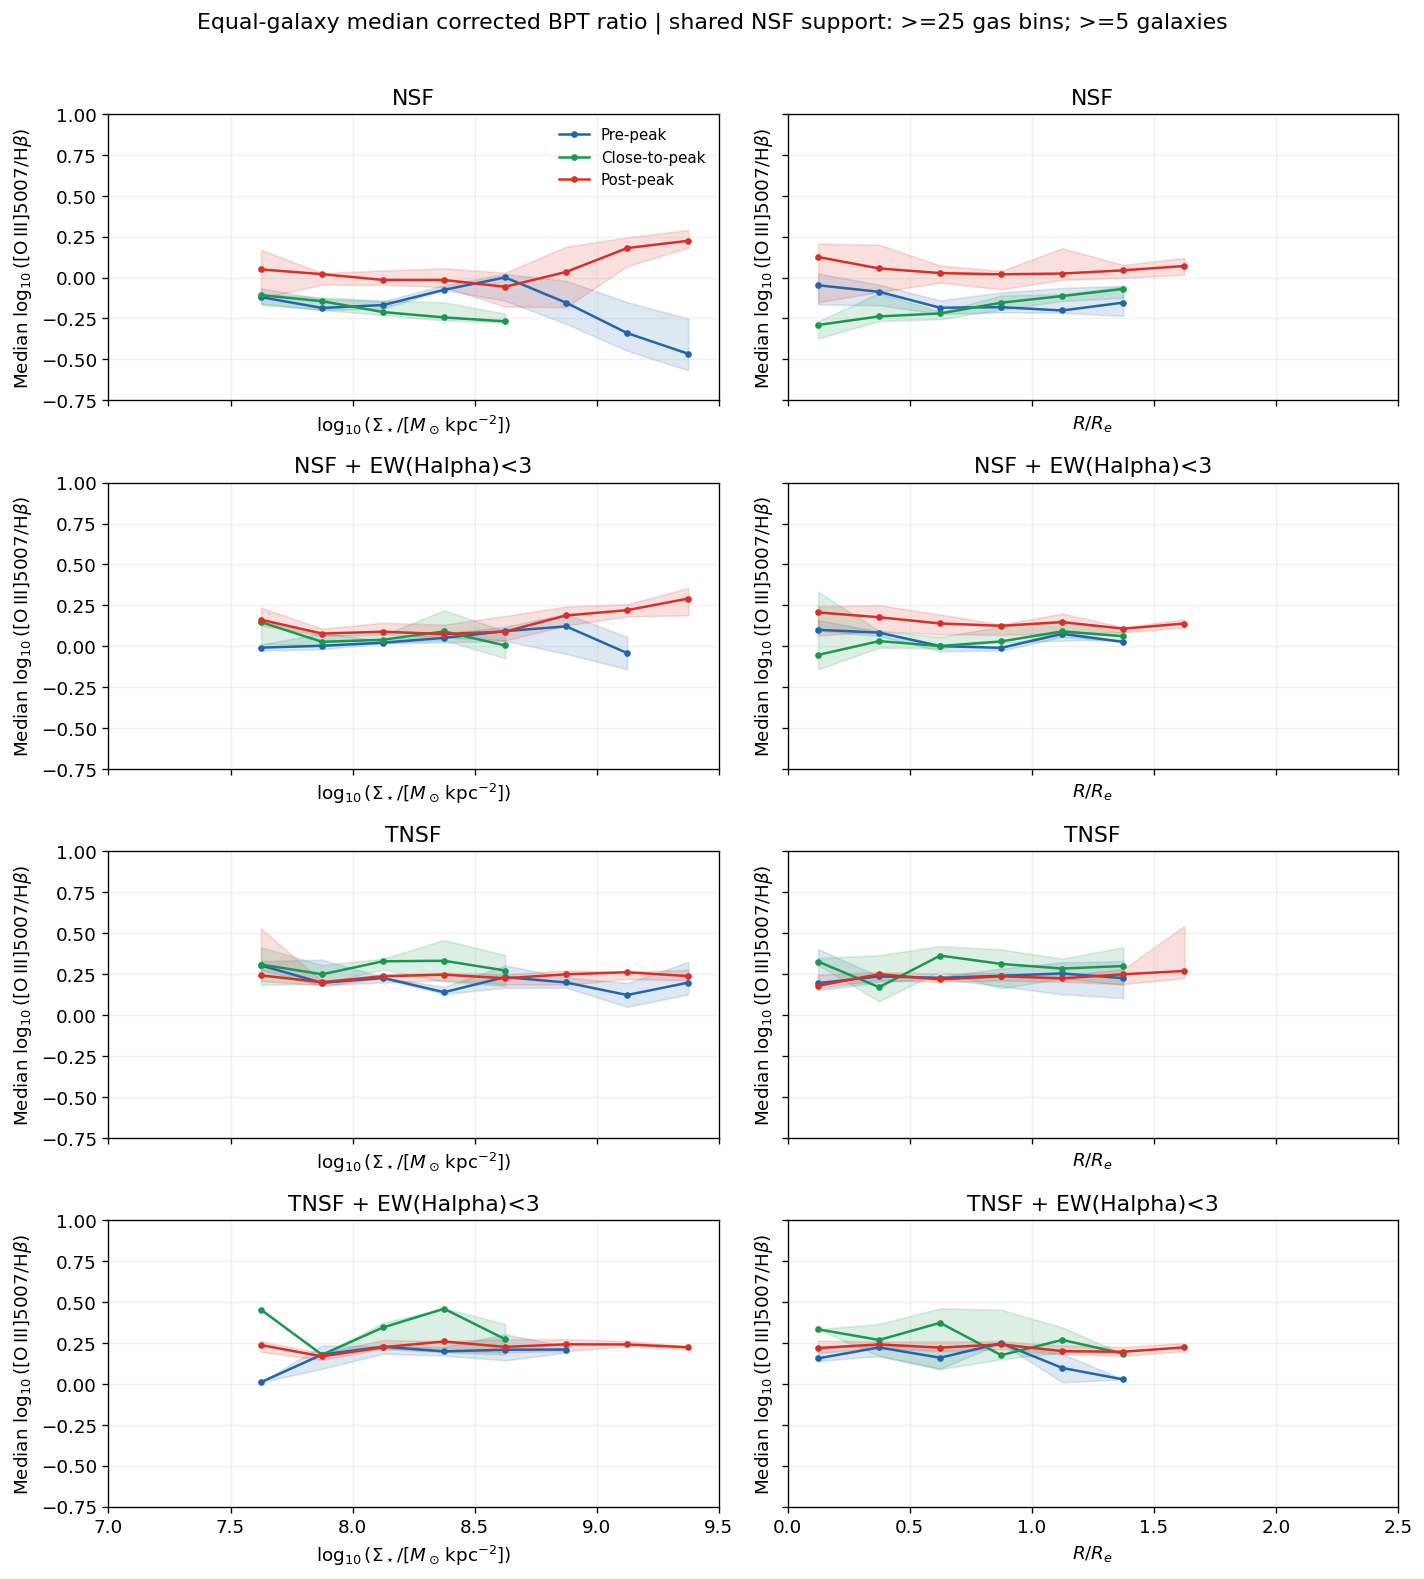

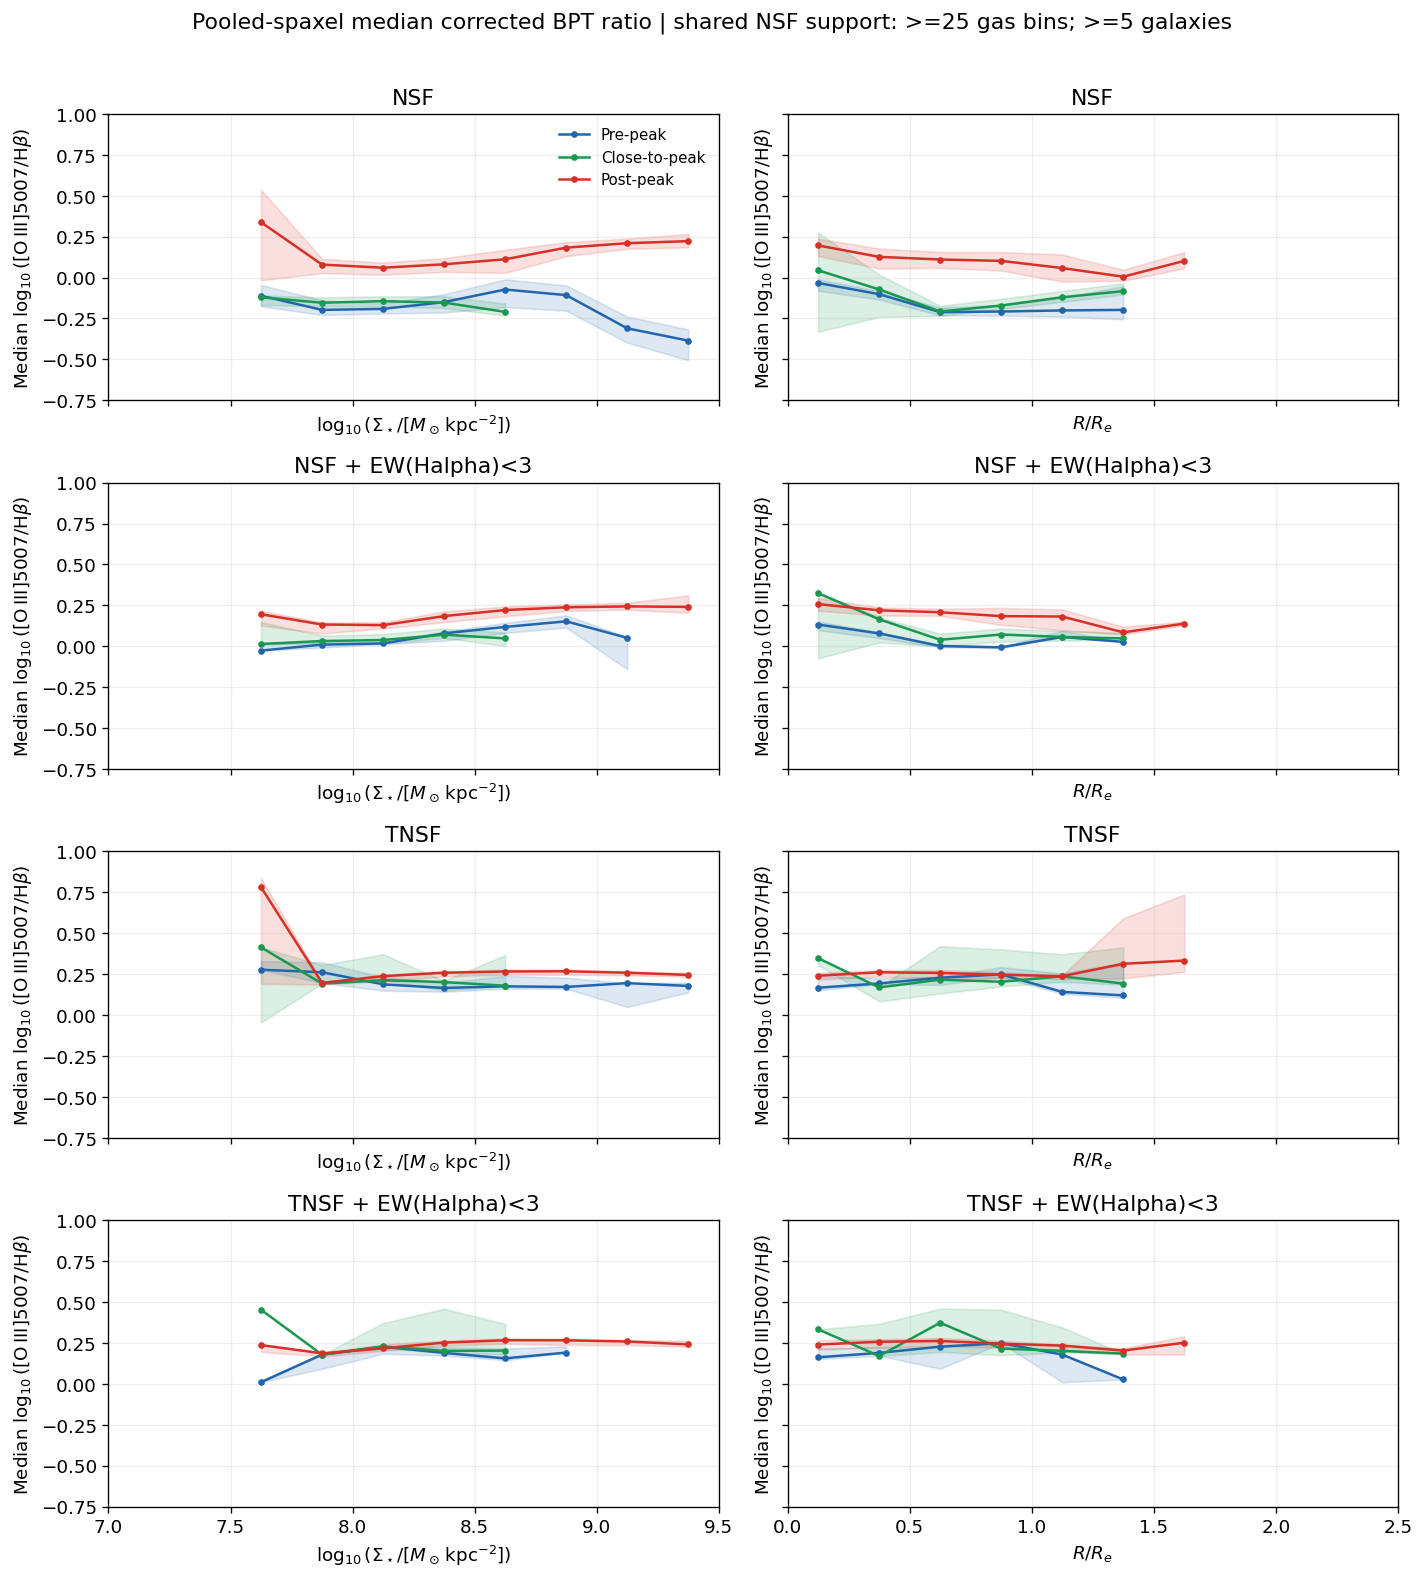

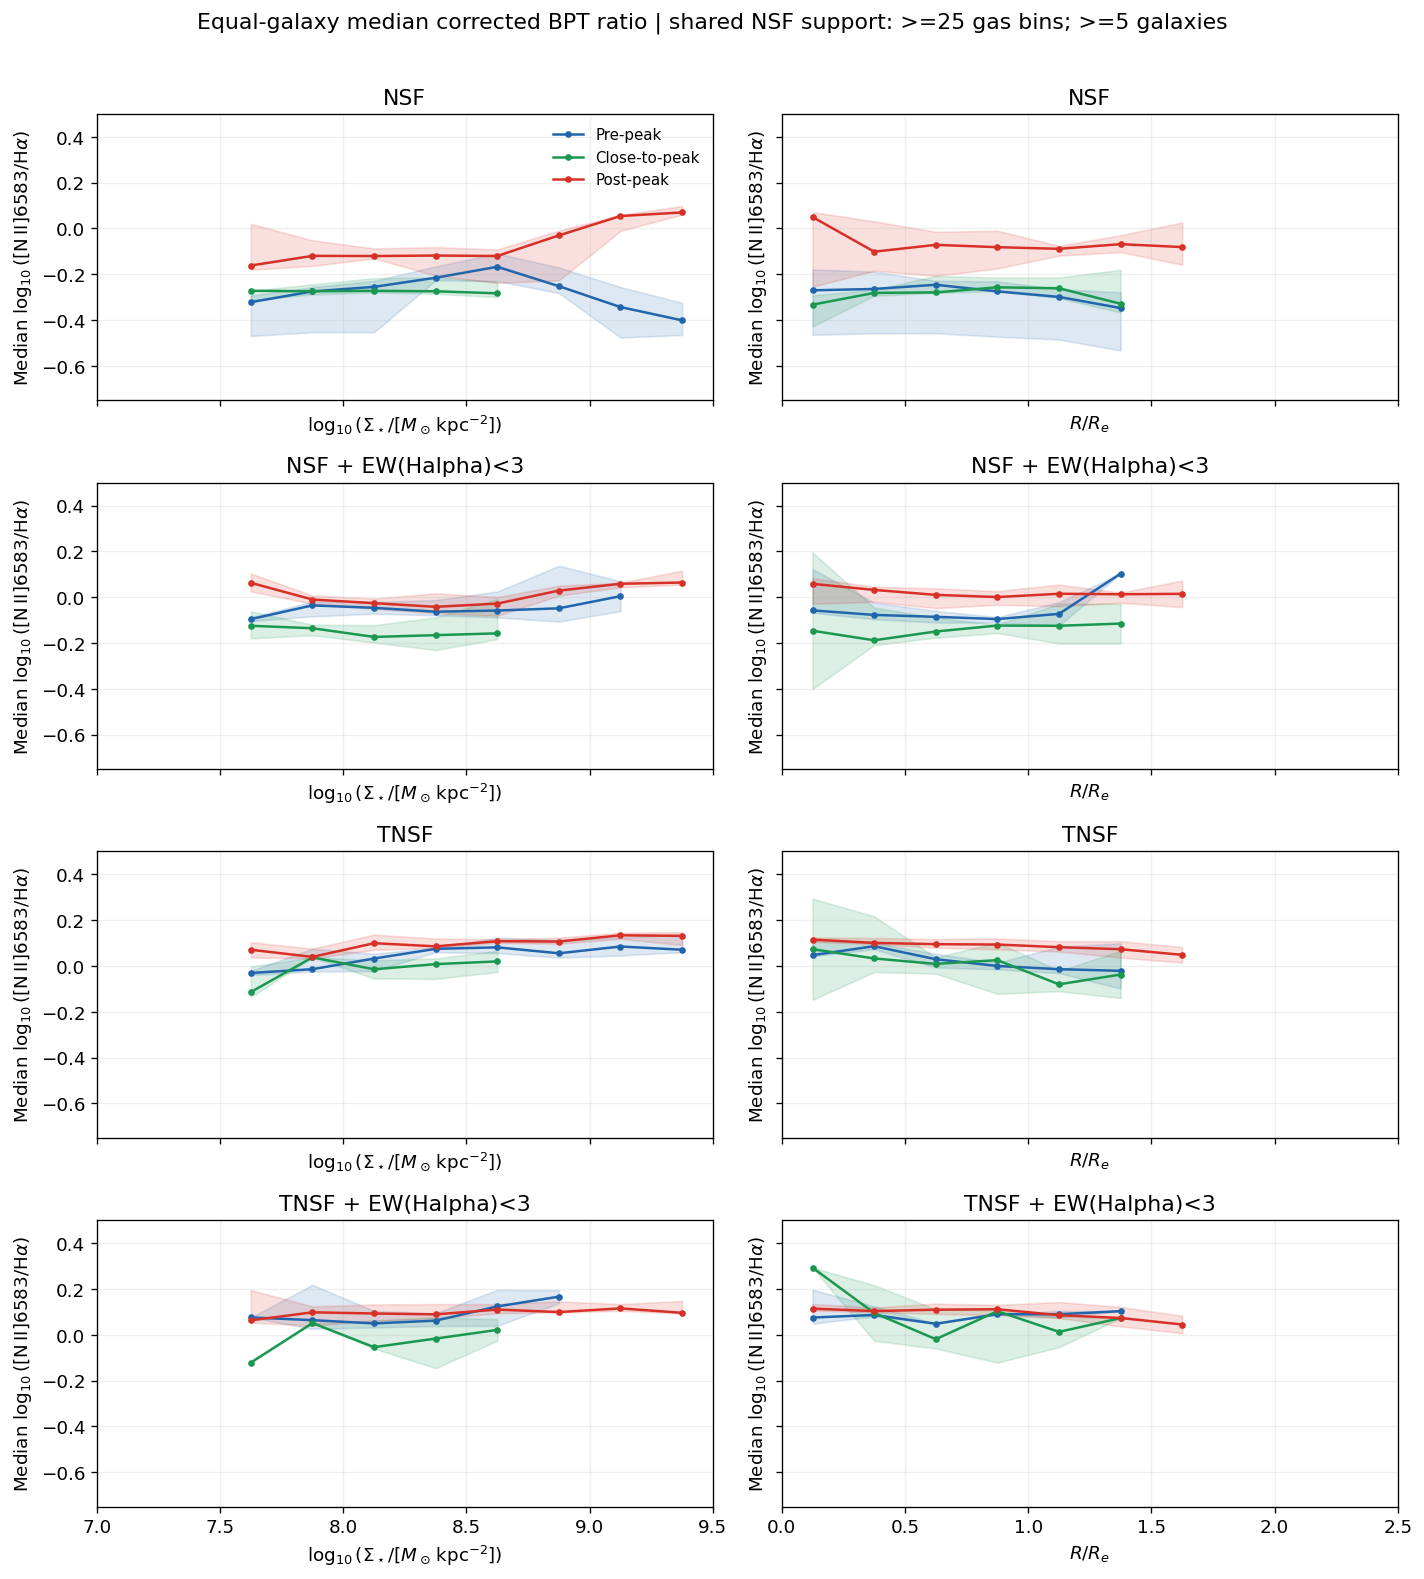

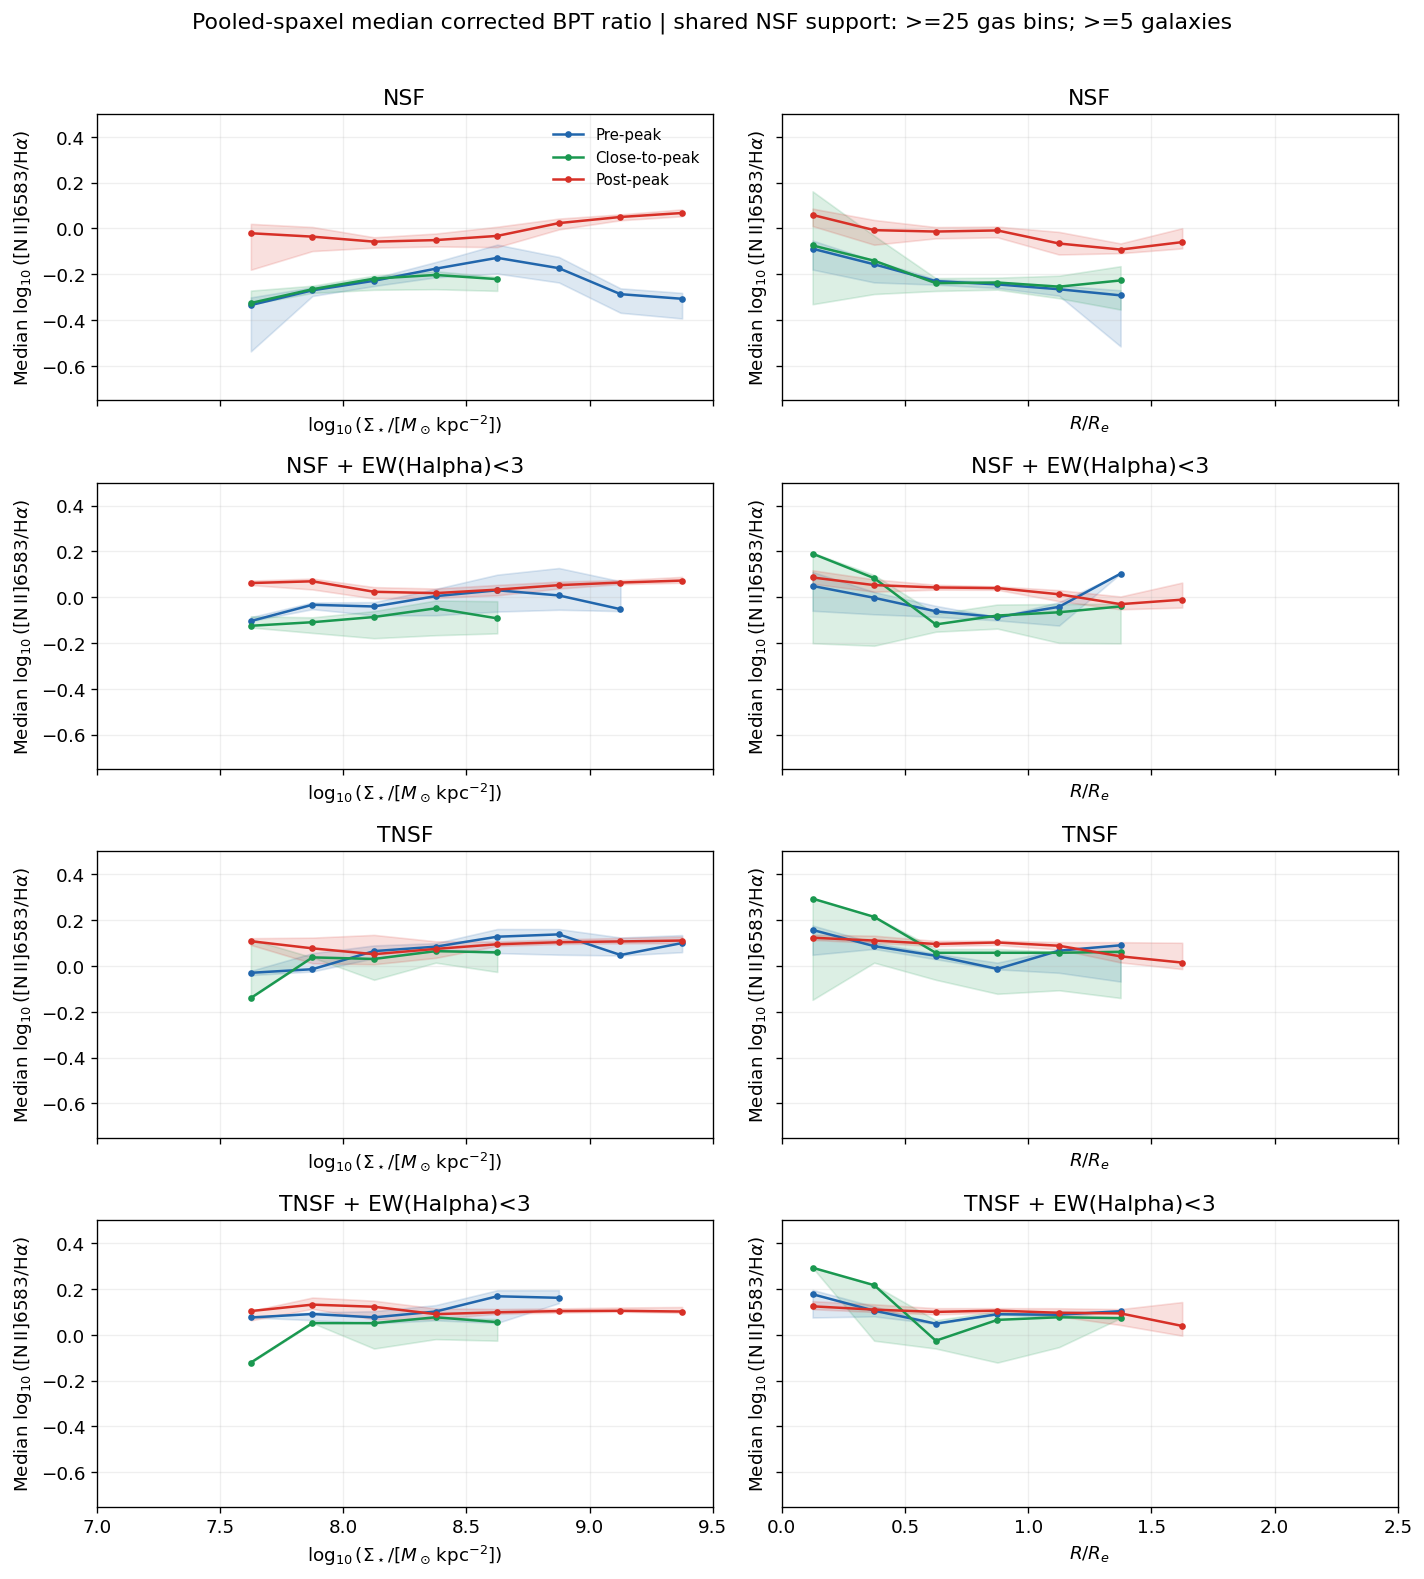

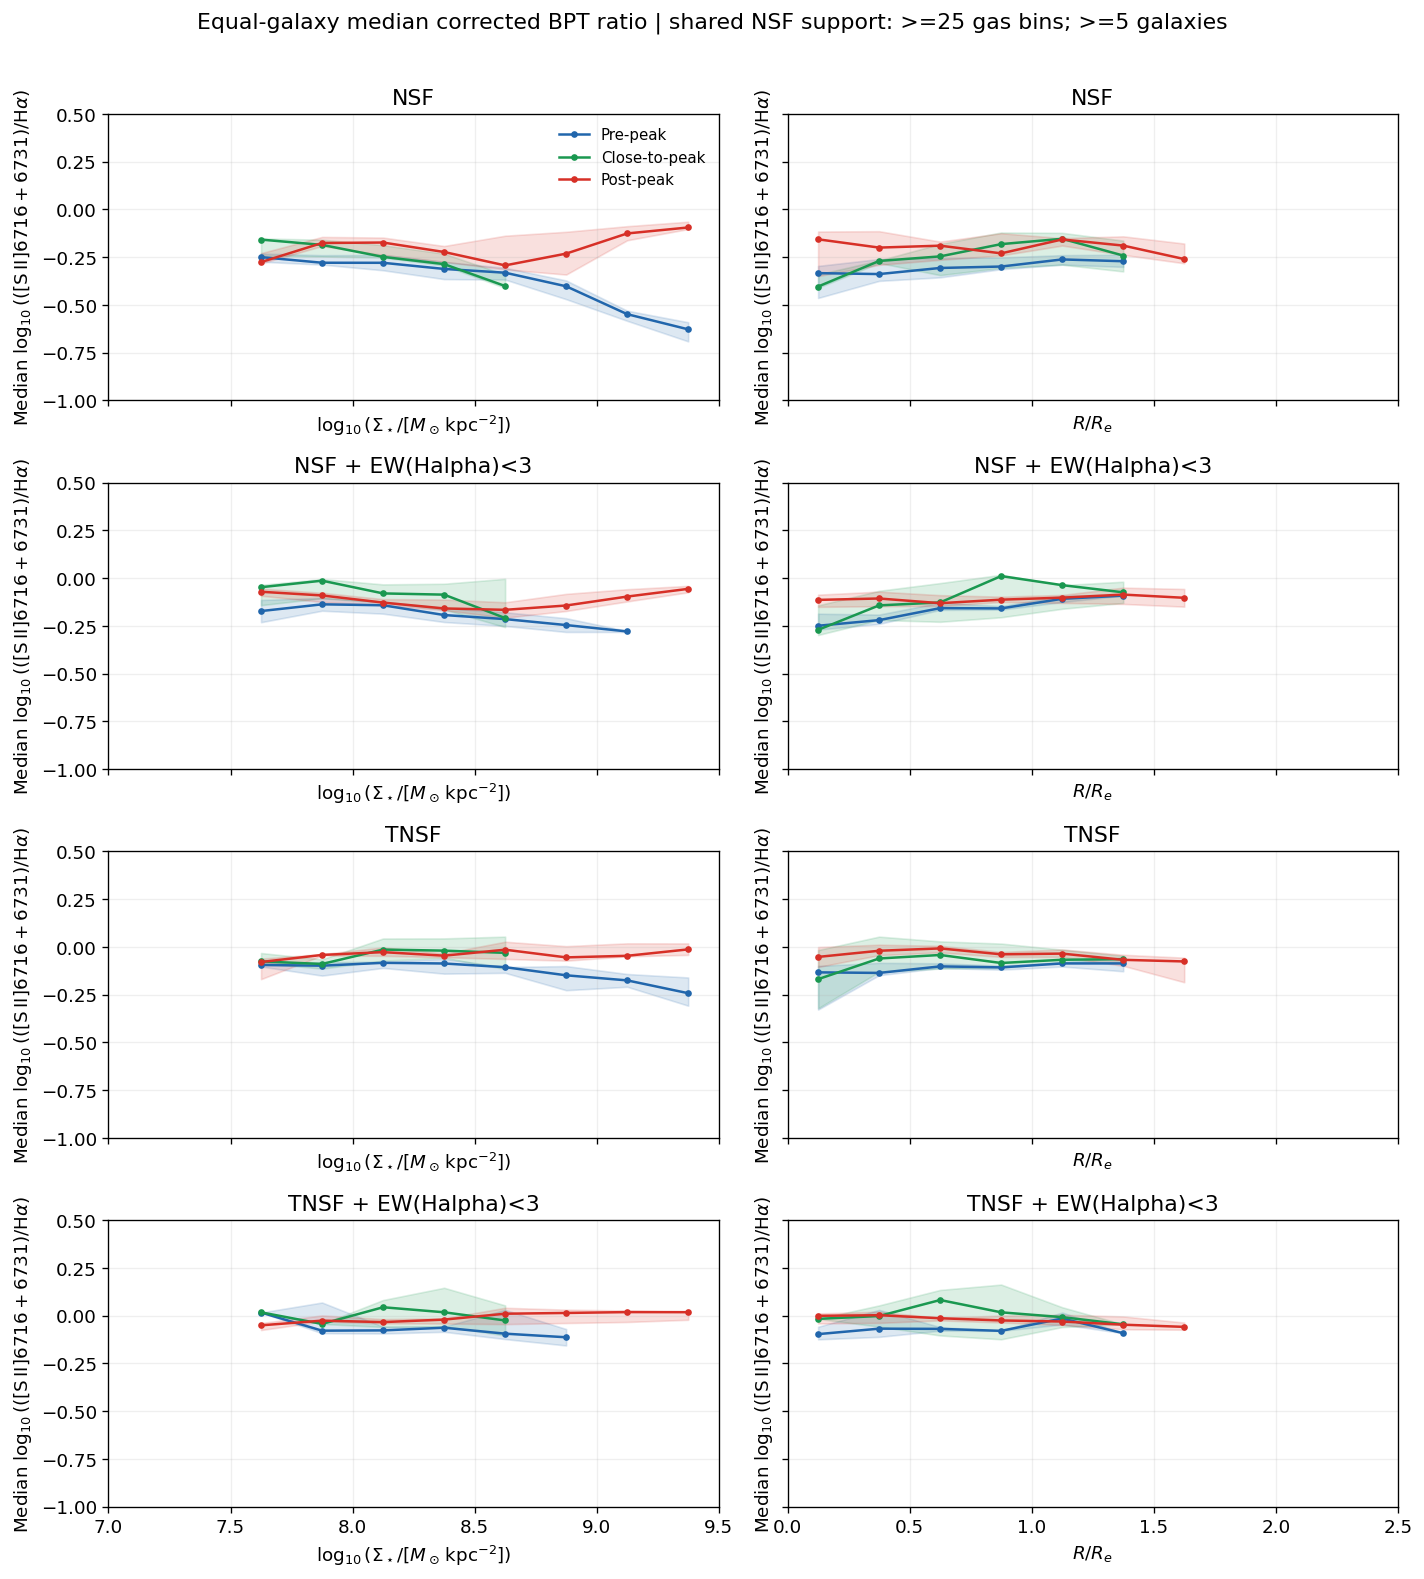

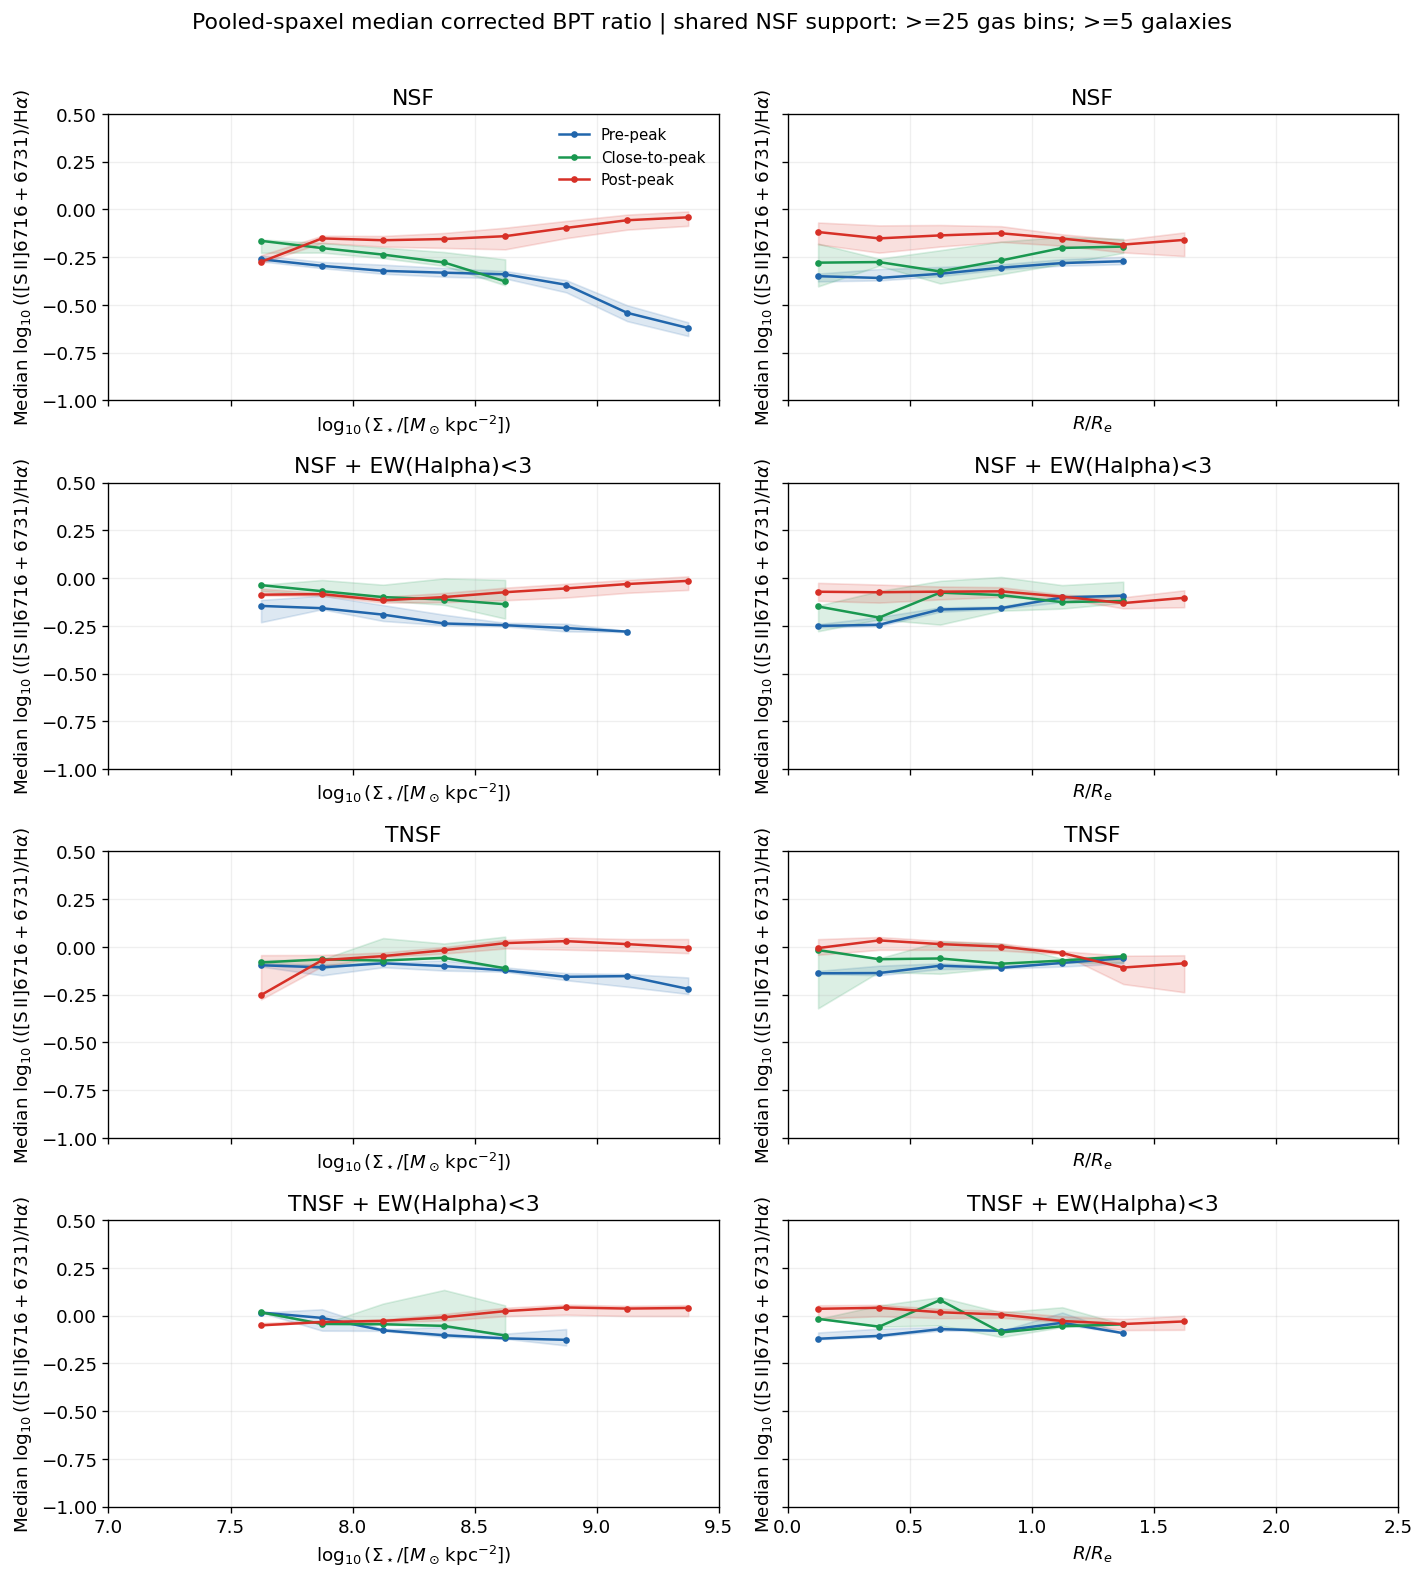

In [8]:
for ratio in RATIO_ORDER:
    for branch in BRANCH_LABELS:
        plot_ratio_profiles(branch,ratio)

## Post-peak NSF ratio maps with cut-aware gray backgrounds

Three rows show the three corrected log ratios, using density-interval support only. The density support decisions and gray classifications match the dispersion maps. The log stellar surface density 7.5 and R/Re=1.5 contours remain on every map. Radial-interval support is not applied to these maps.


In [9]:
POSTPEAK_SAMPLE=sample.loc[sample.stage.eq("post-peak")].sort_values("GALID")
POSTPEAK_EXCLUDED=SAMPLE_QC.loc[SAMPLE_QC.stage.eq("post-peak")&SAMPLE_QC.QC_flag.ne("OK"),["GALID","QC_flag"]]
display(POSTPEAK_EXCLUDED)


,GALID,QC_flag
14,NGC4548,missing_mass_product;missing_sfr_product;missi...
16,NGC4579,missing_mass_product;missing_sfr_product;missi...
19,NGC4689,missing_mass_product;missing_sfr_product;missi...


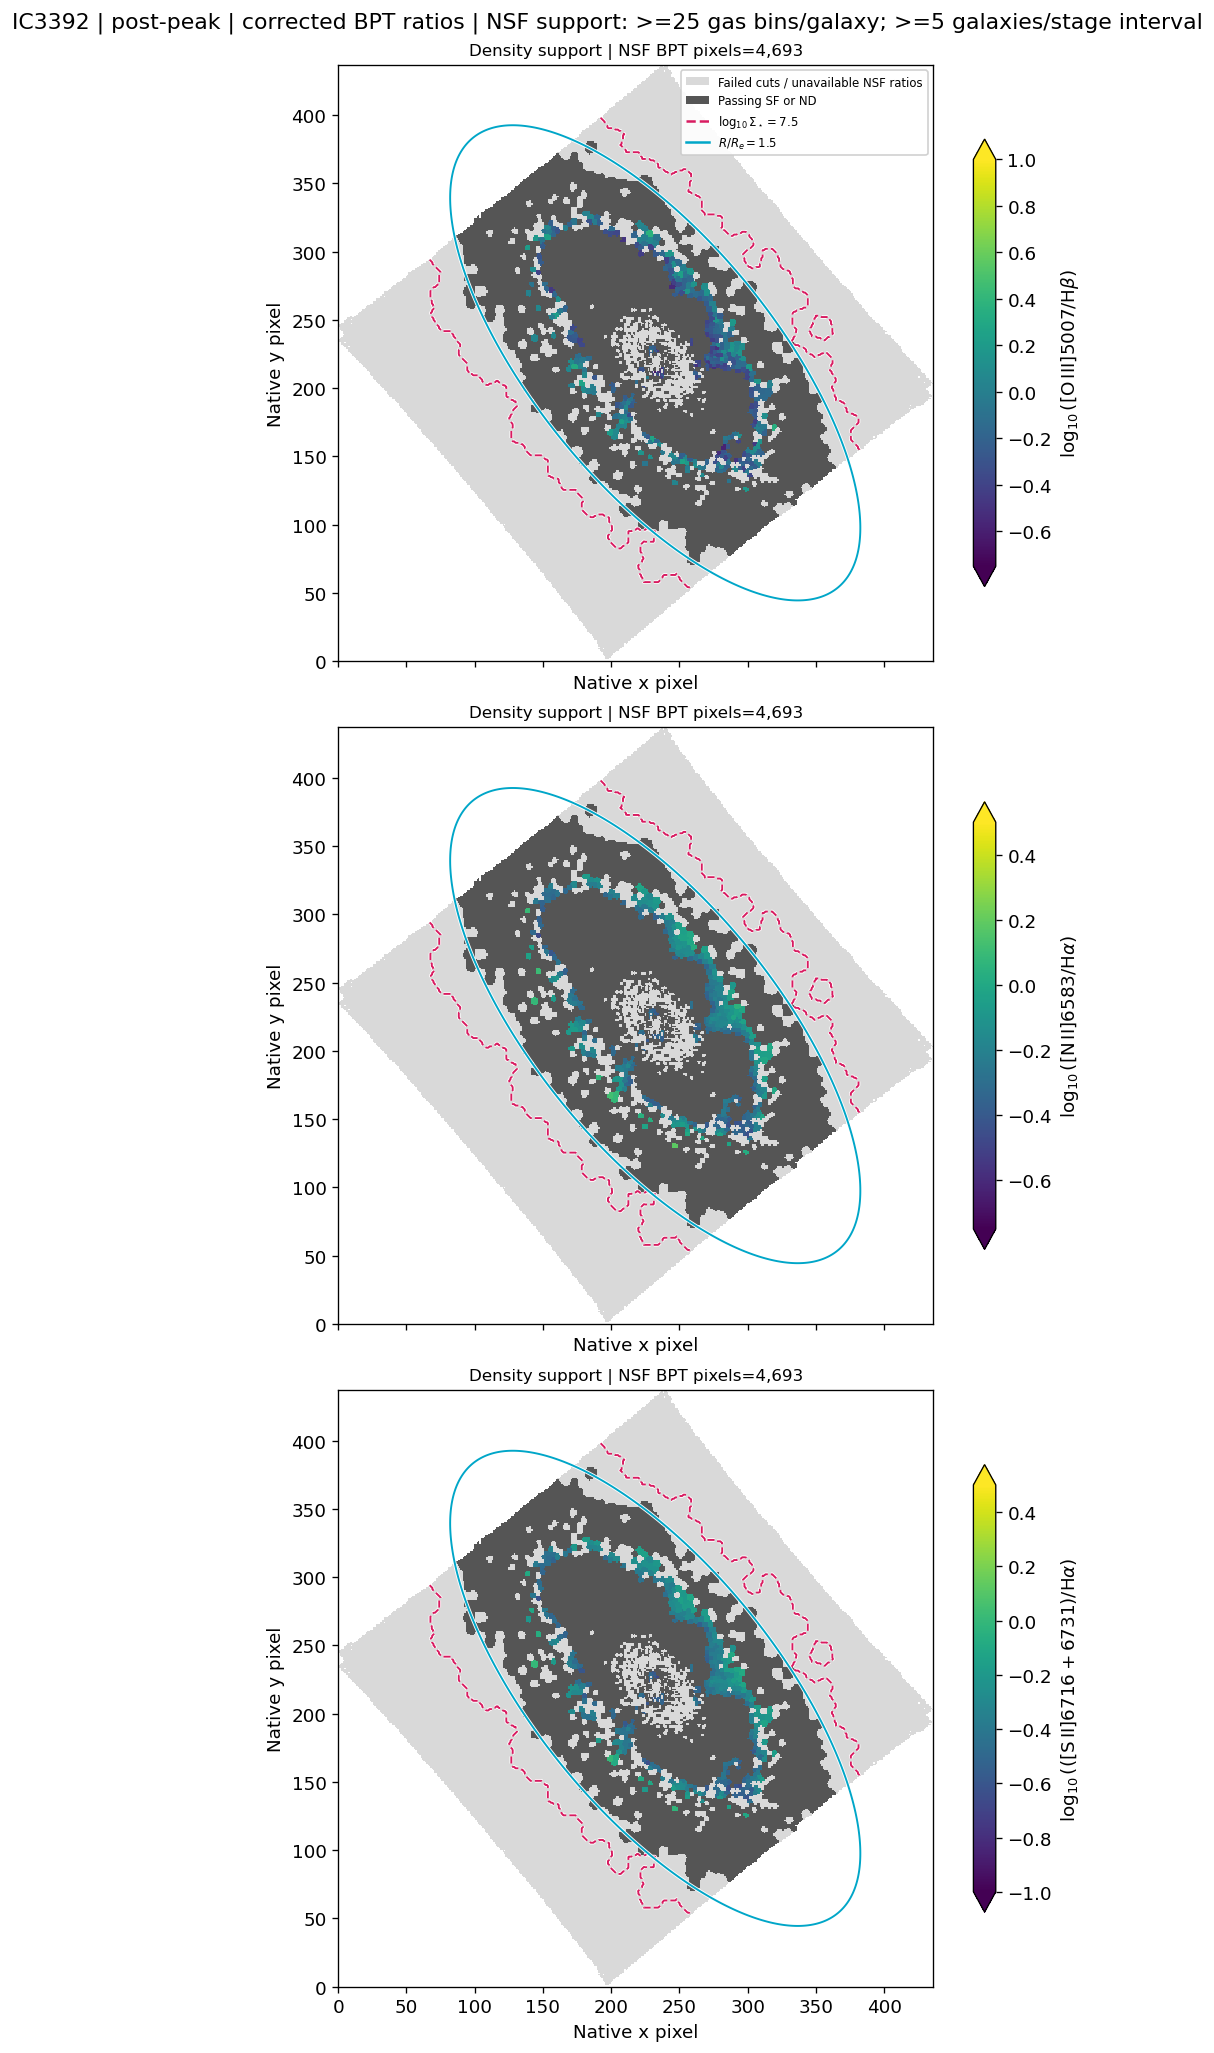

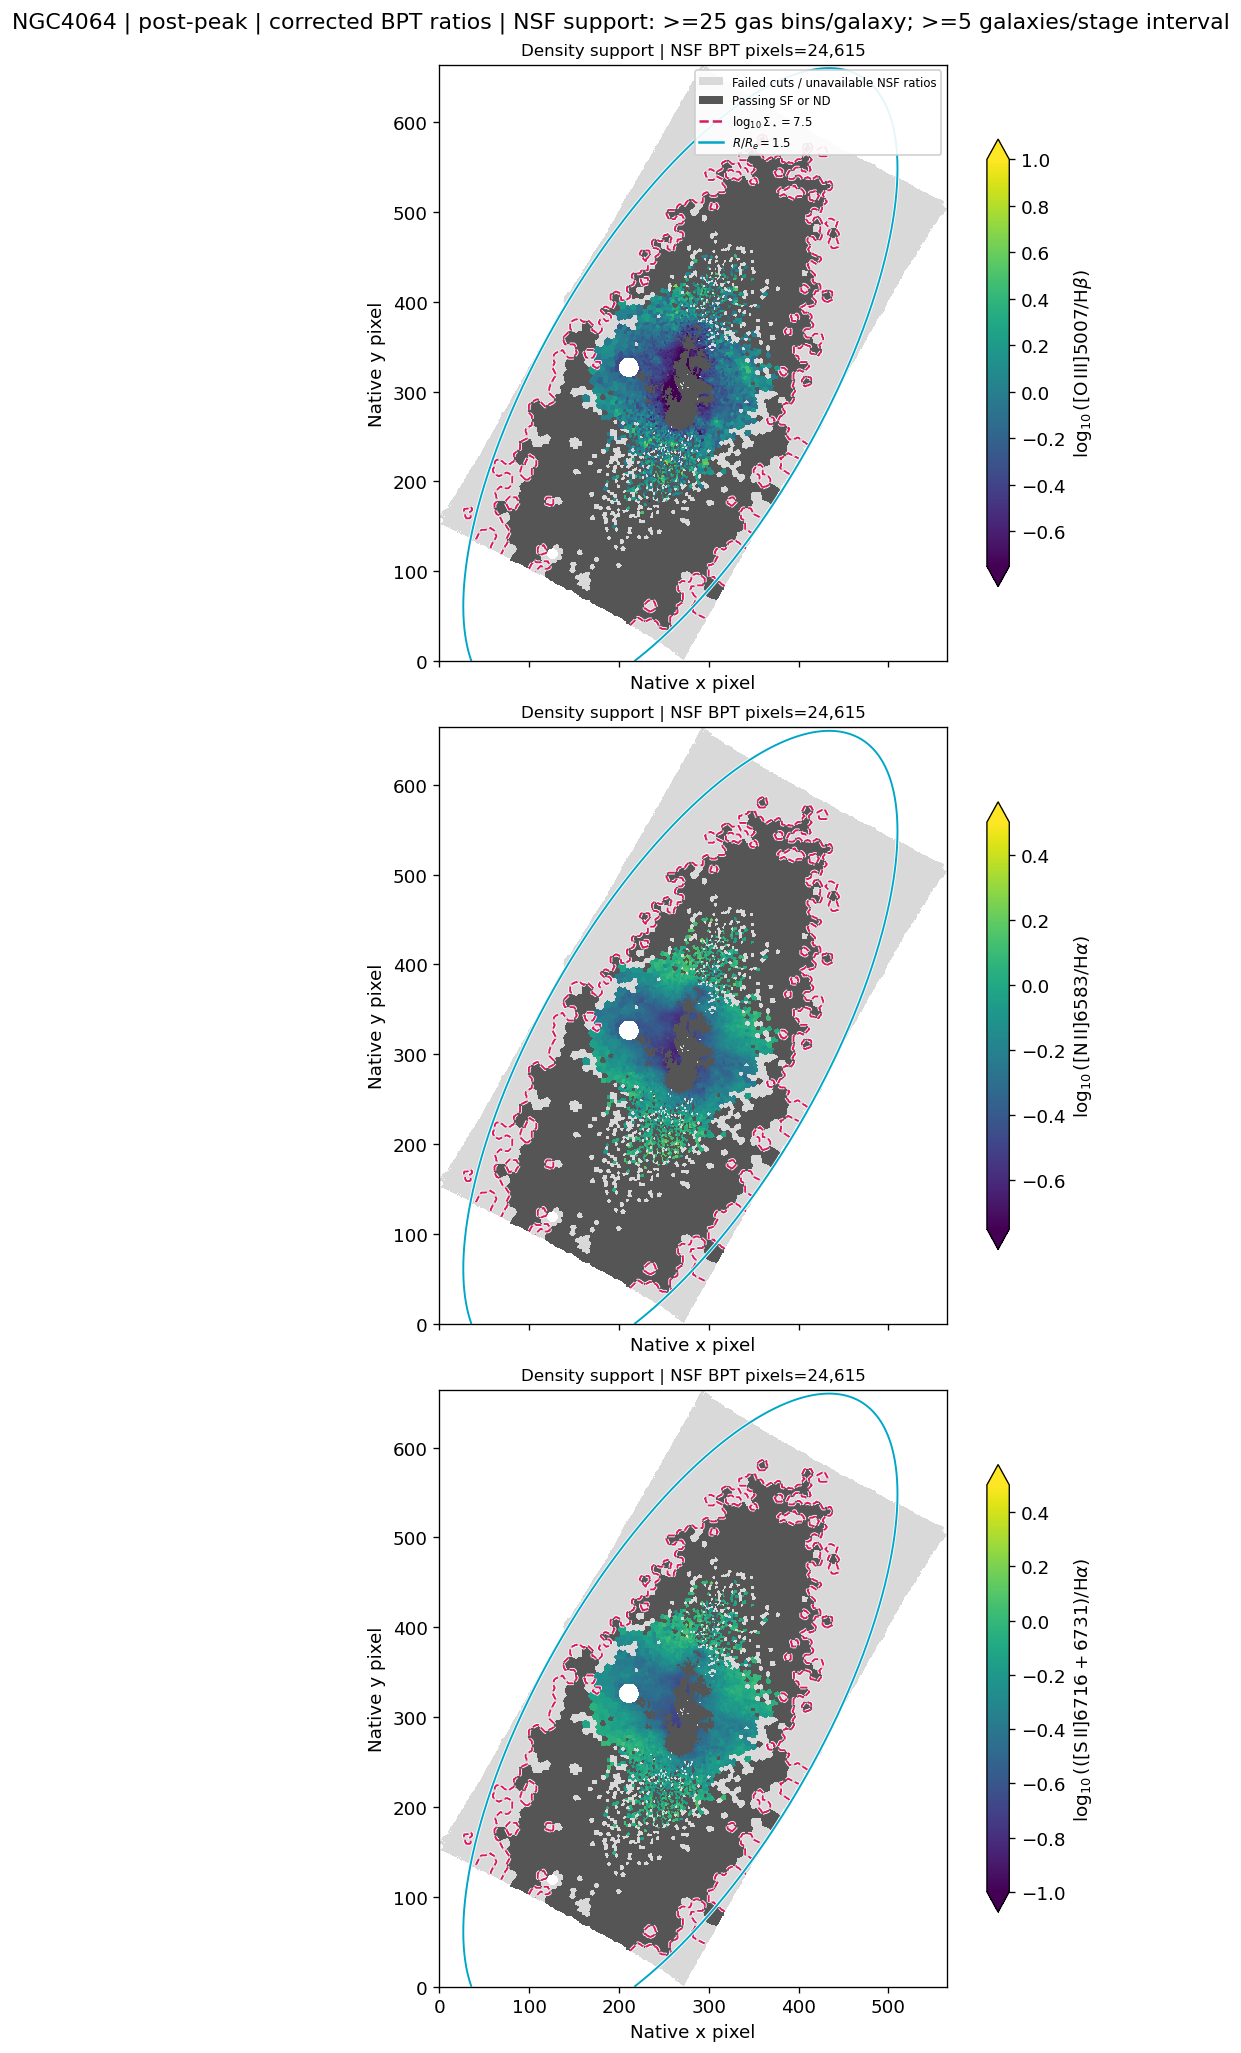

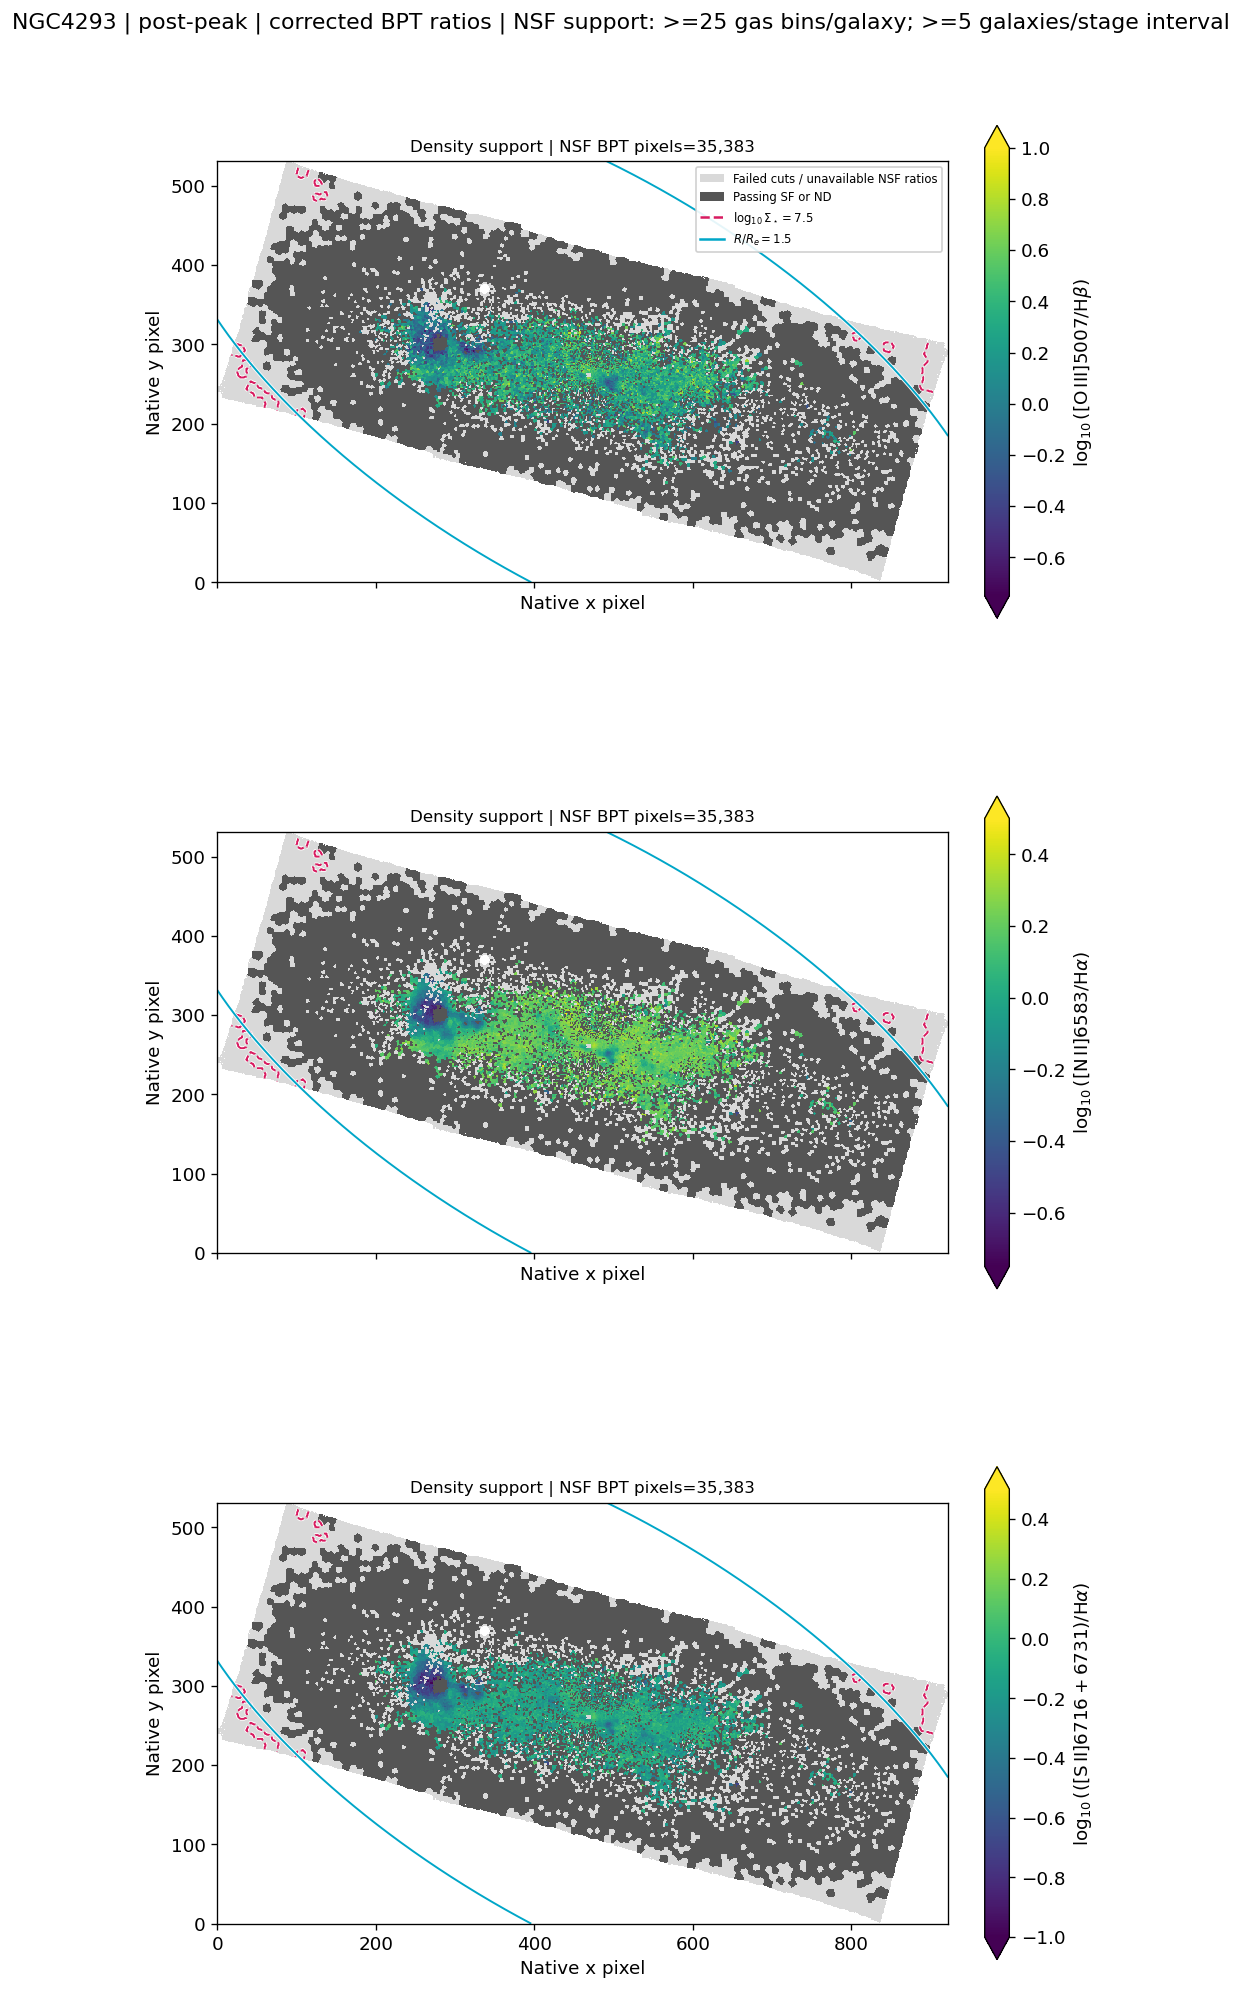

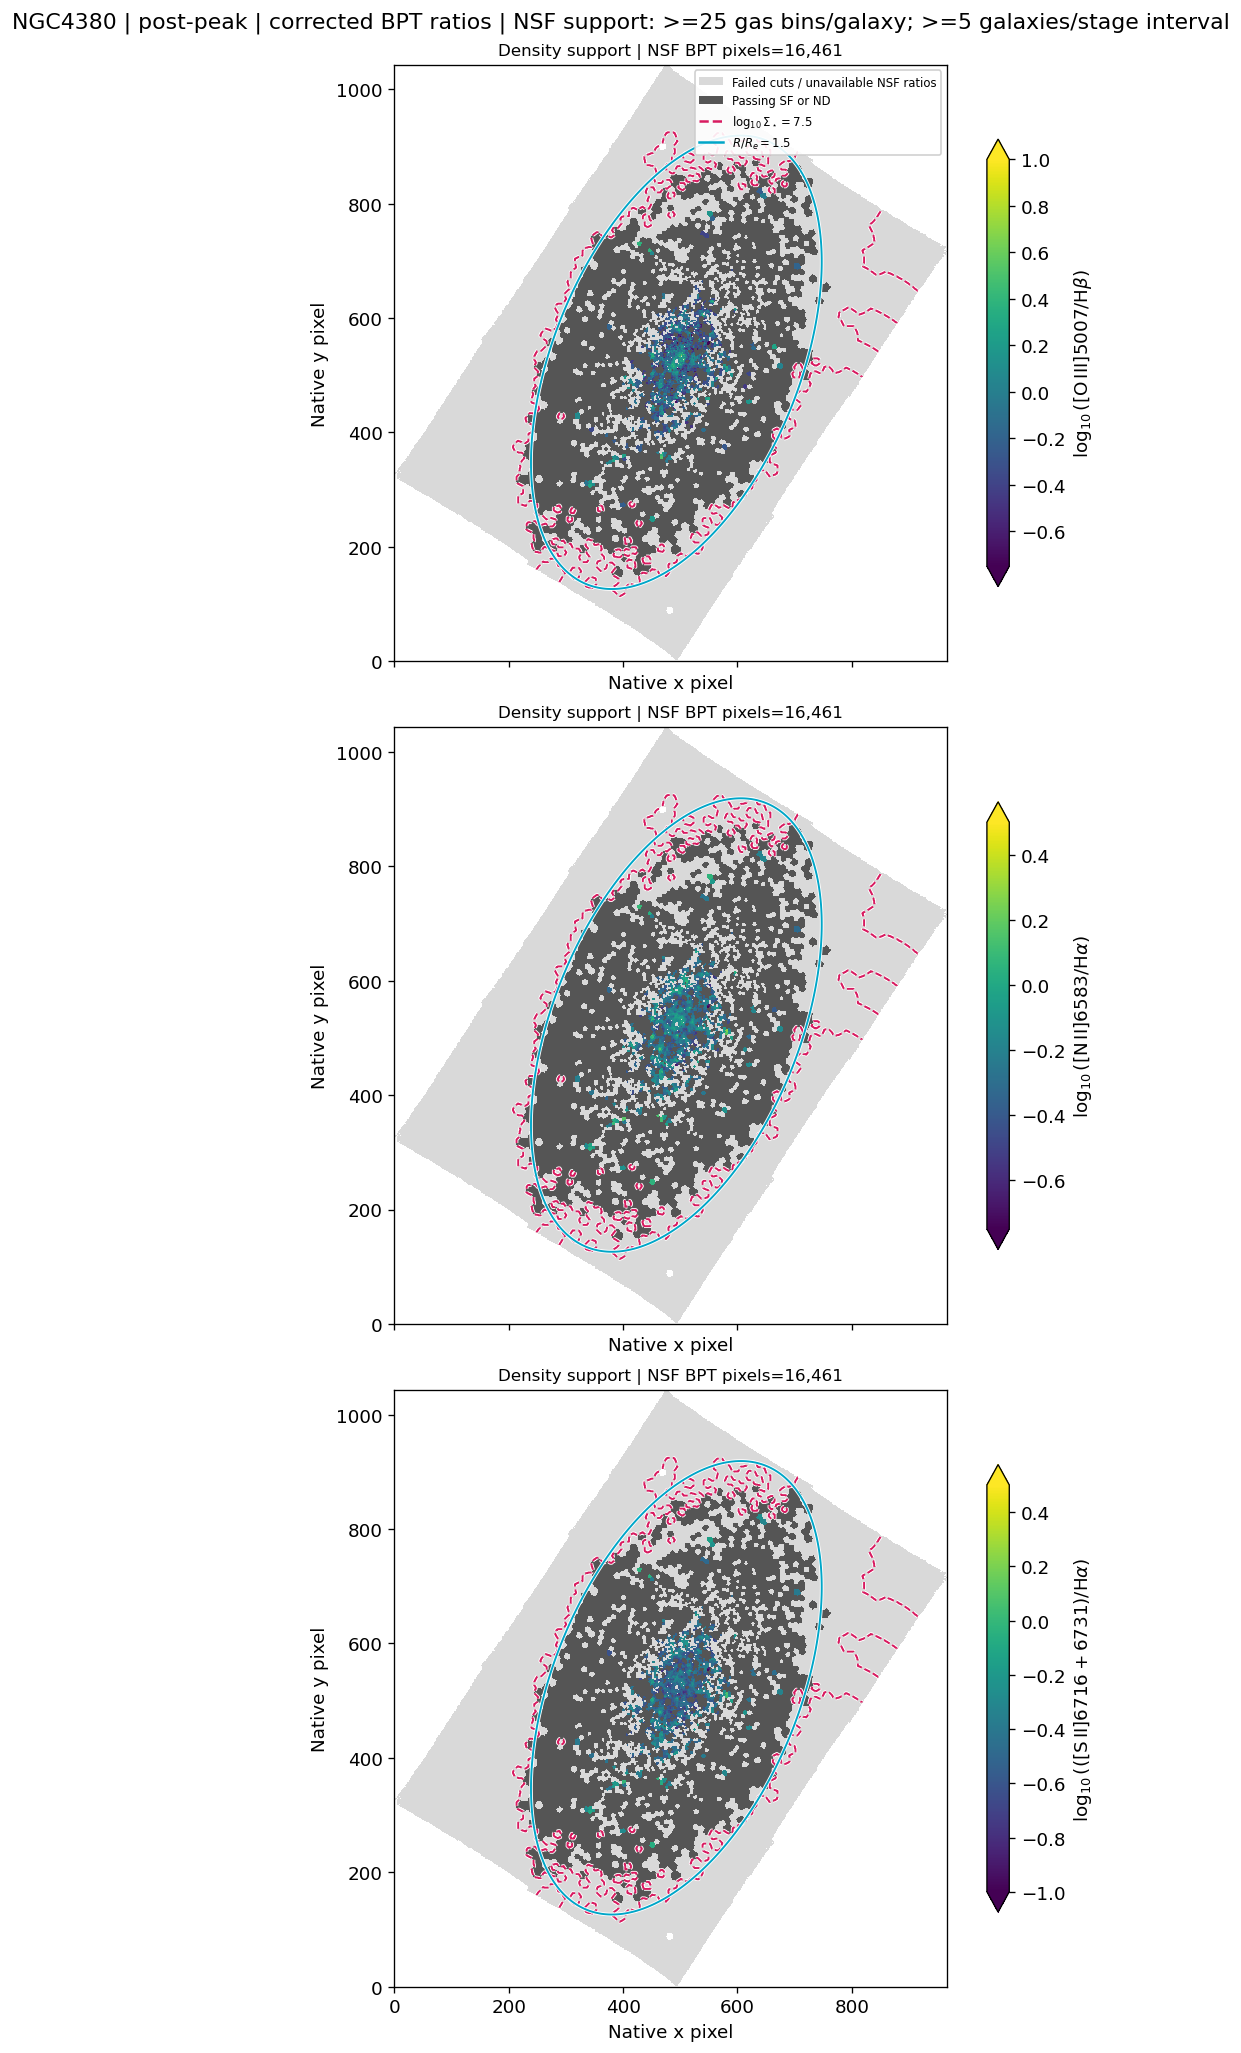

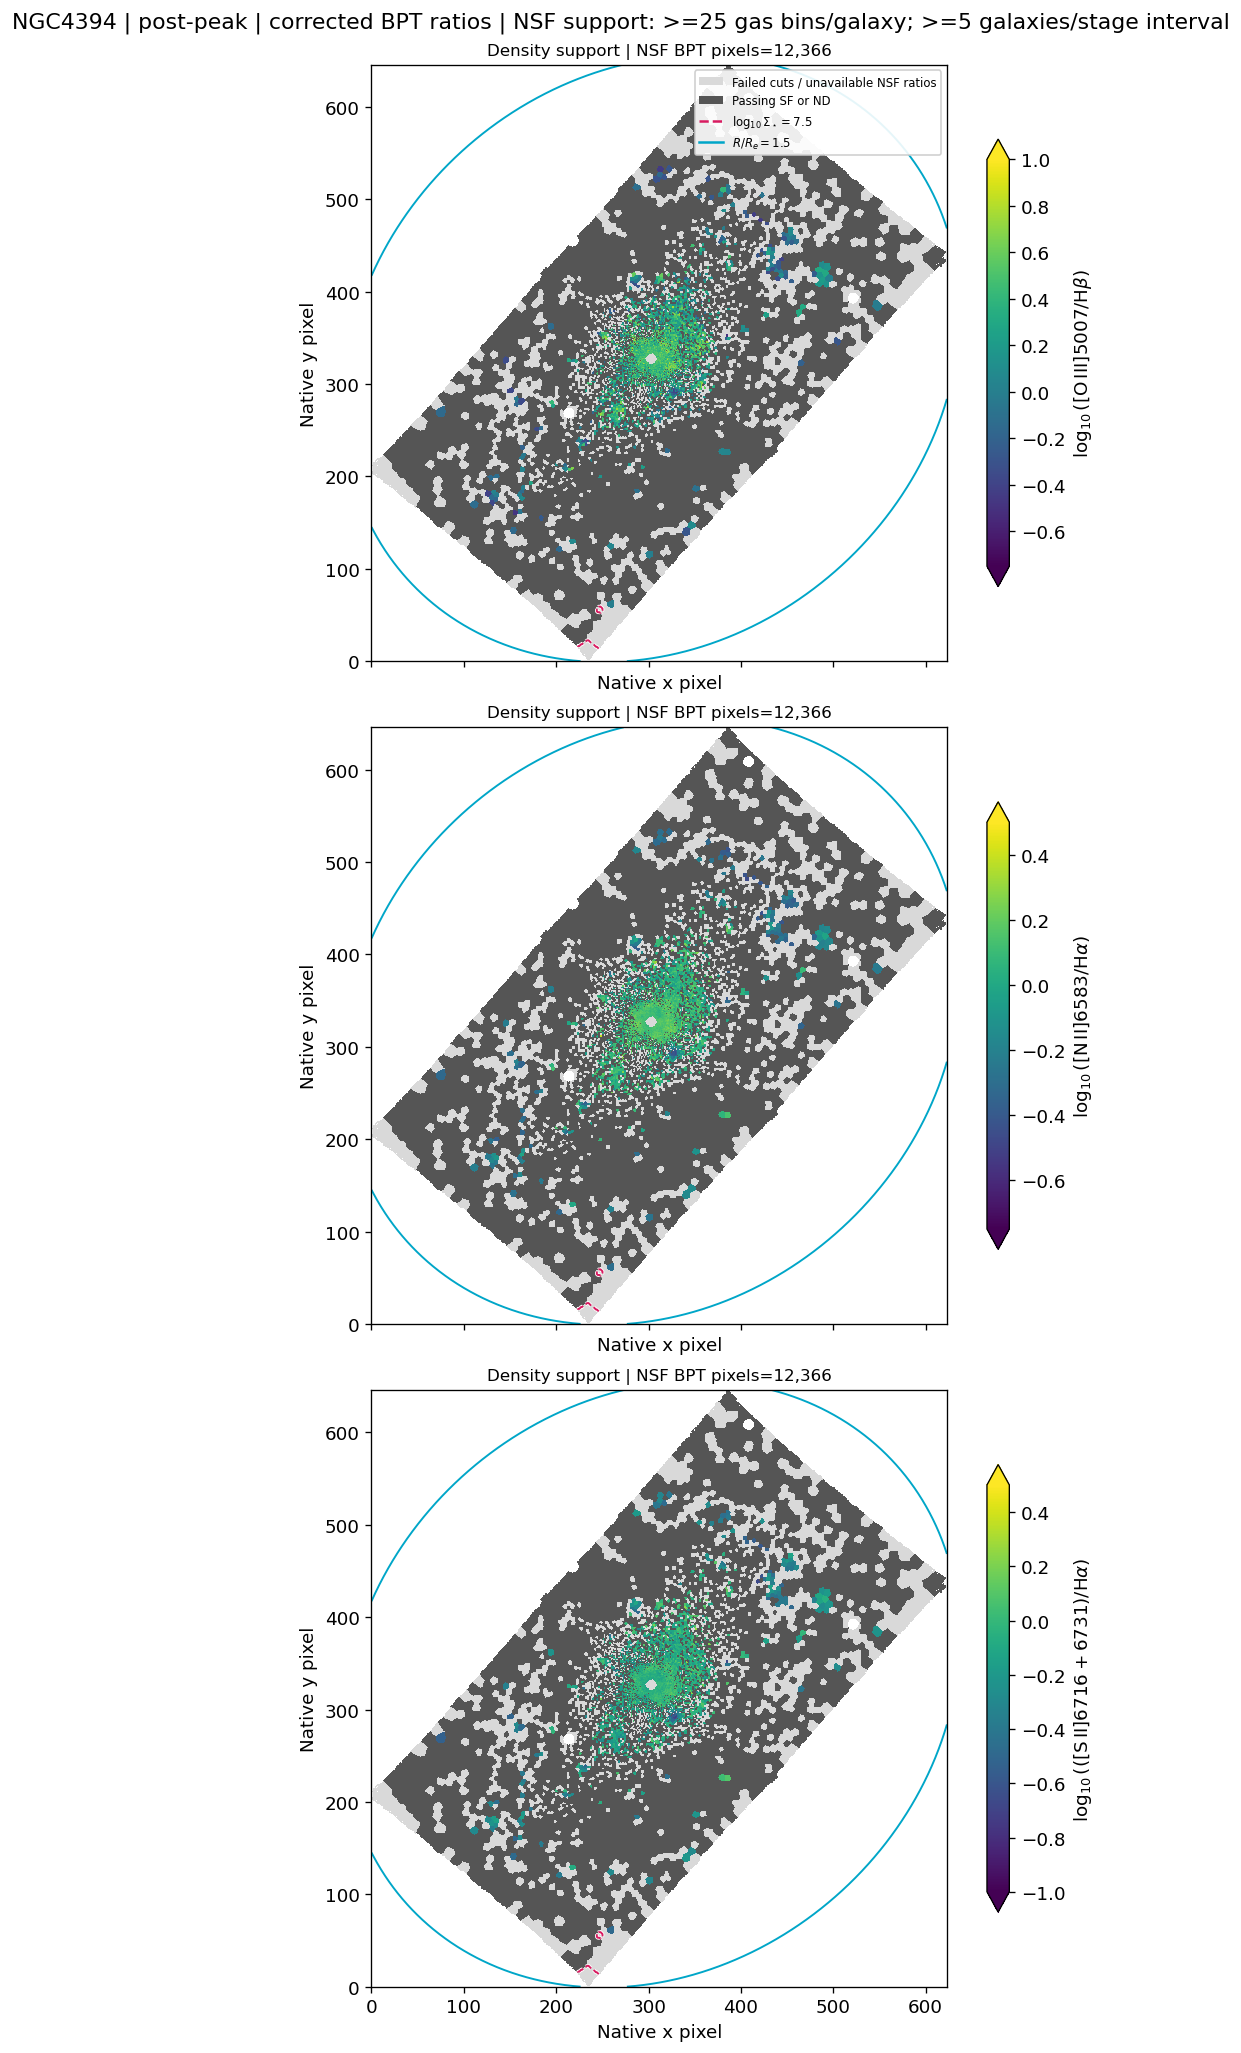

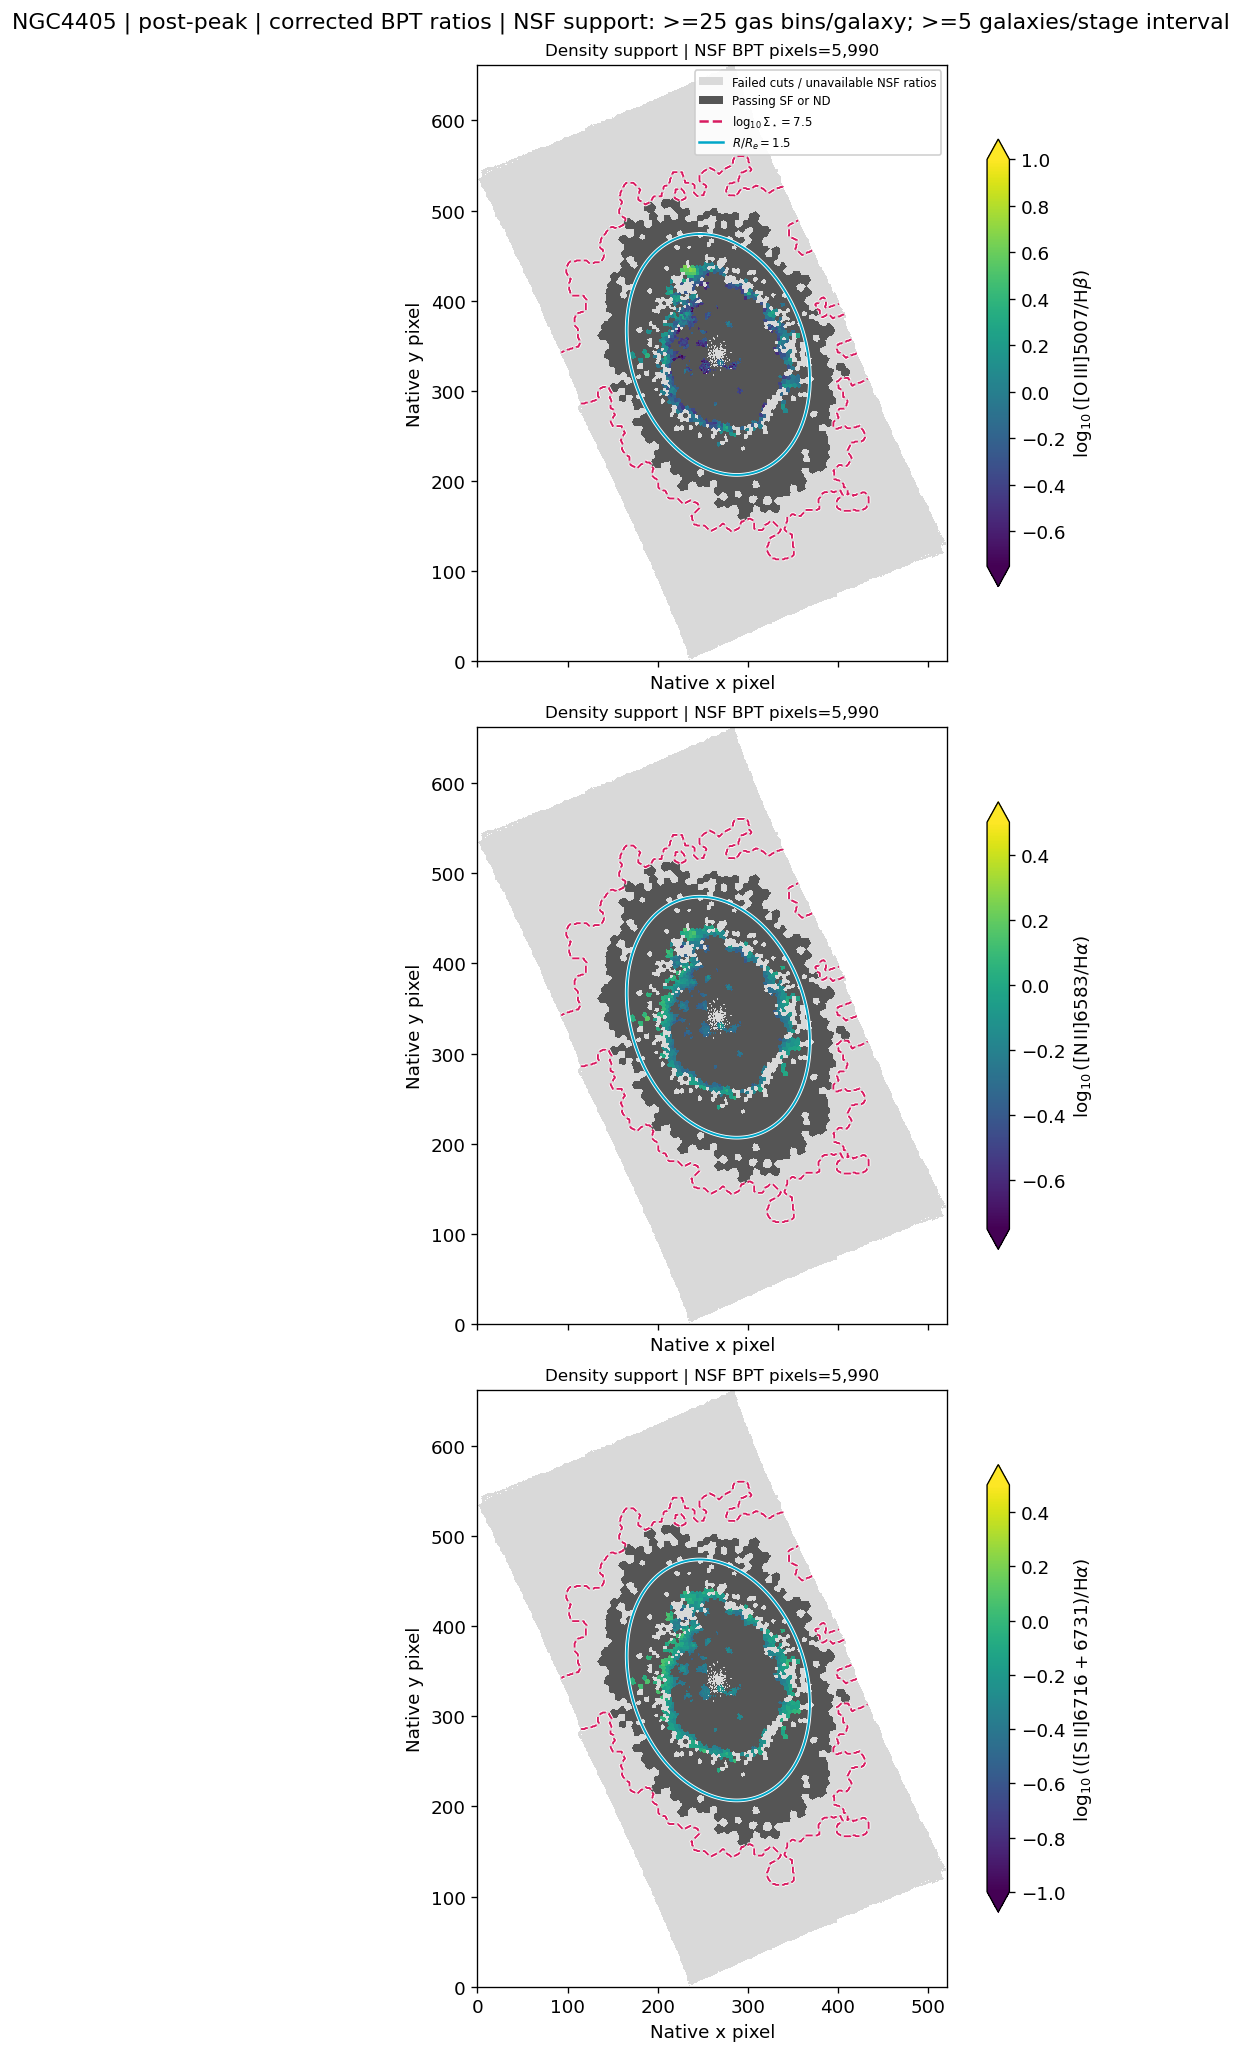

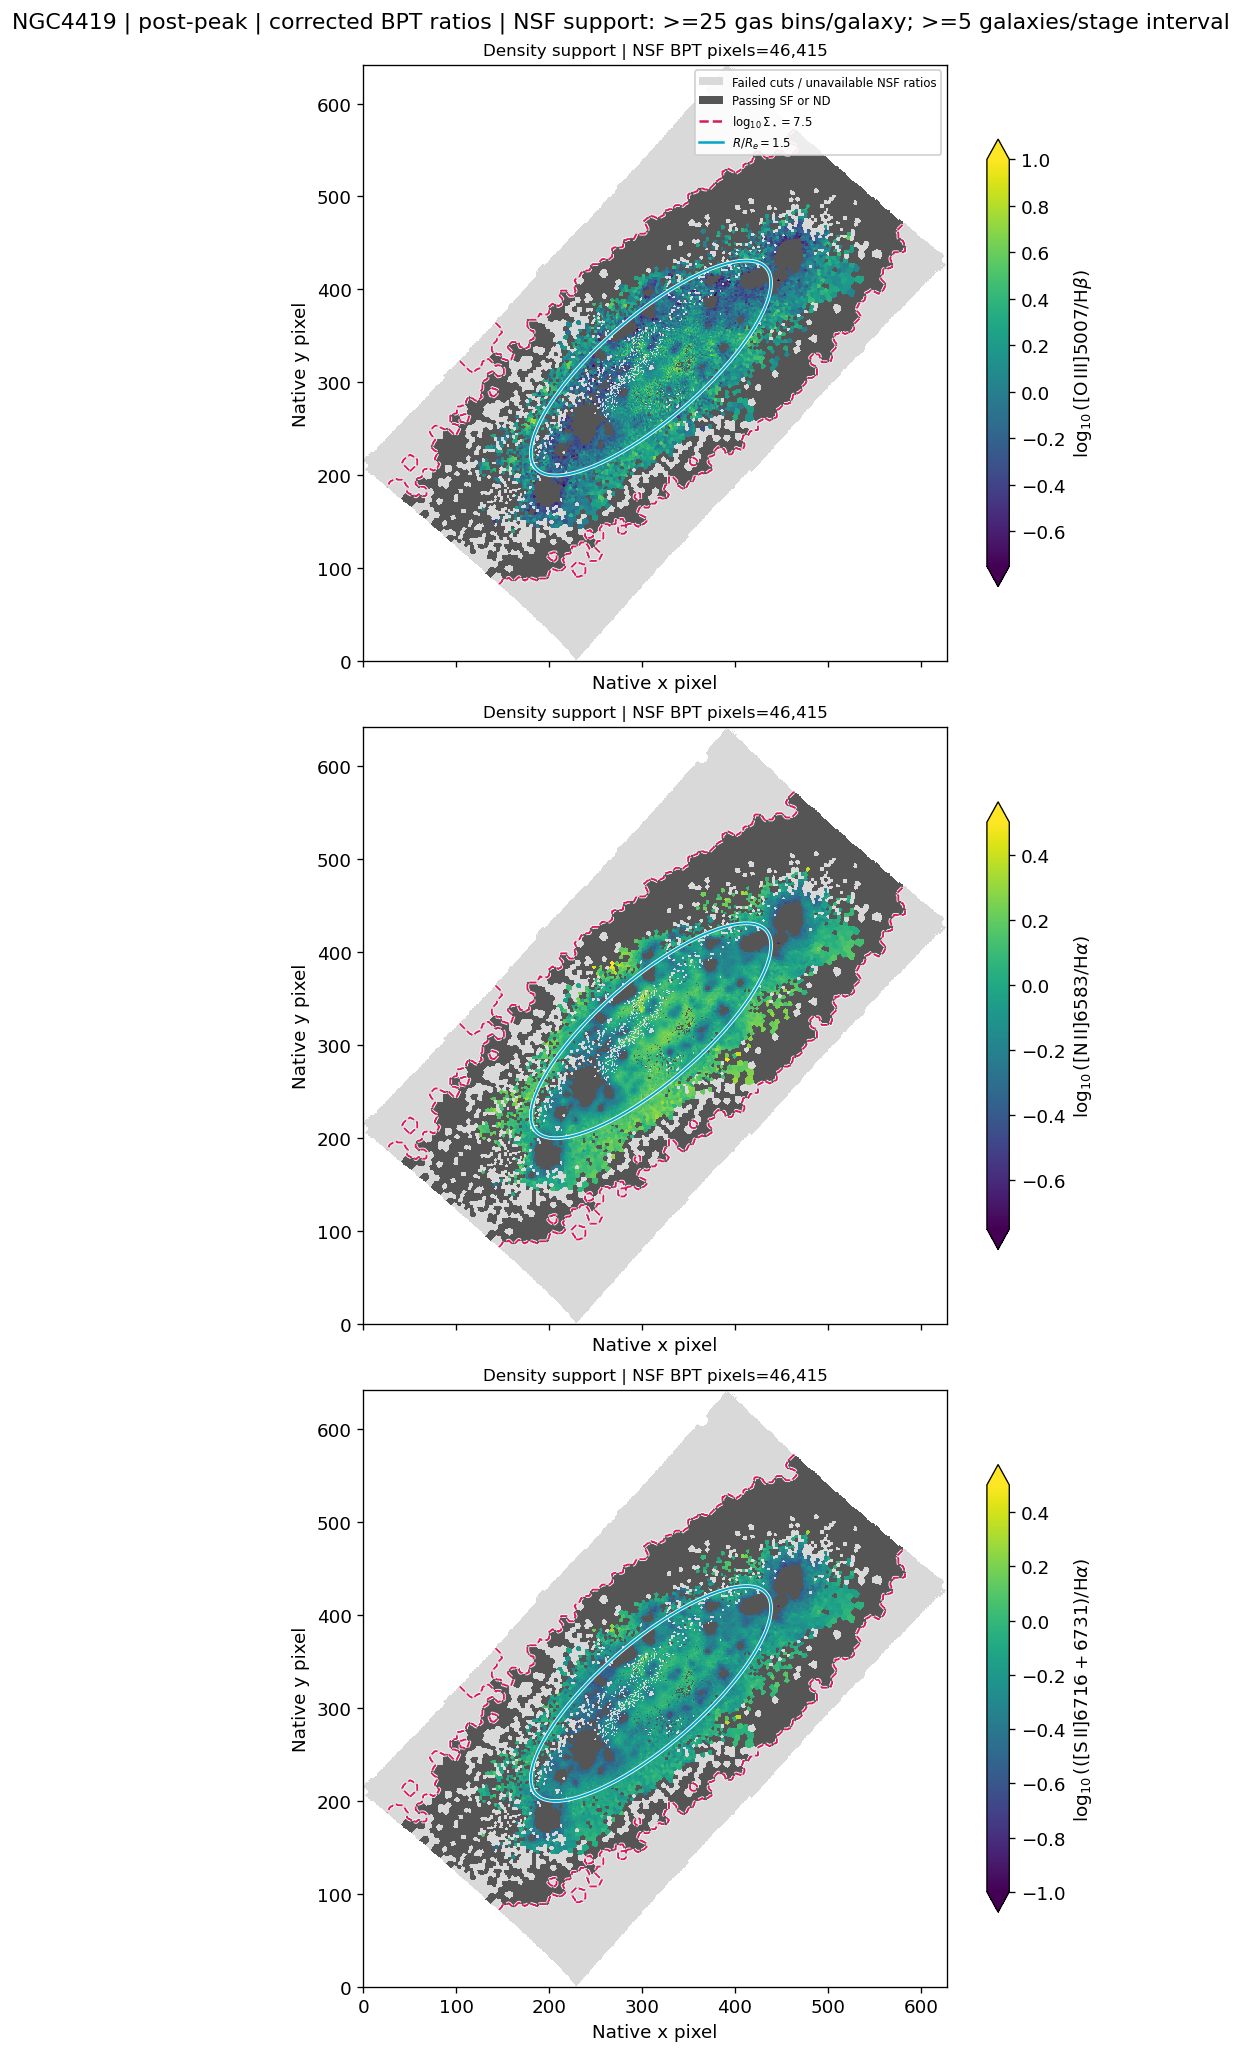

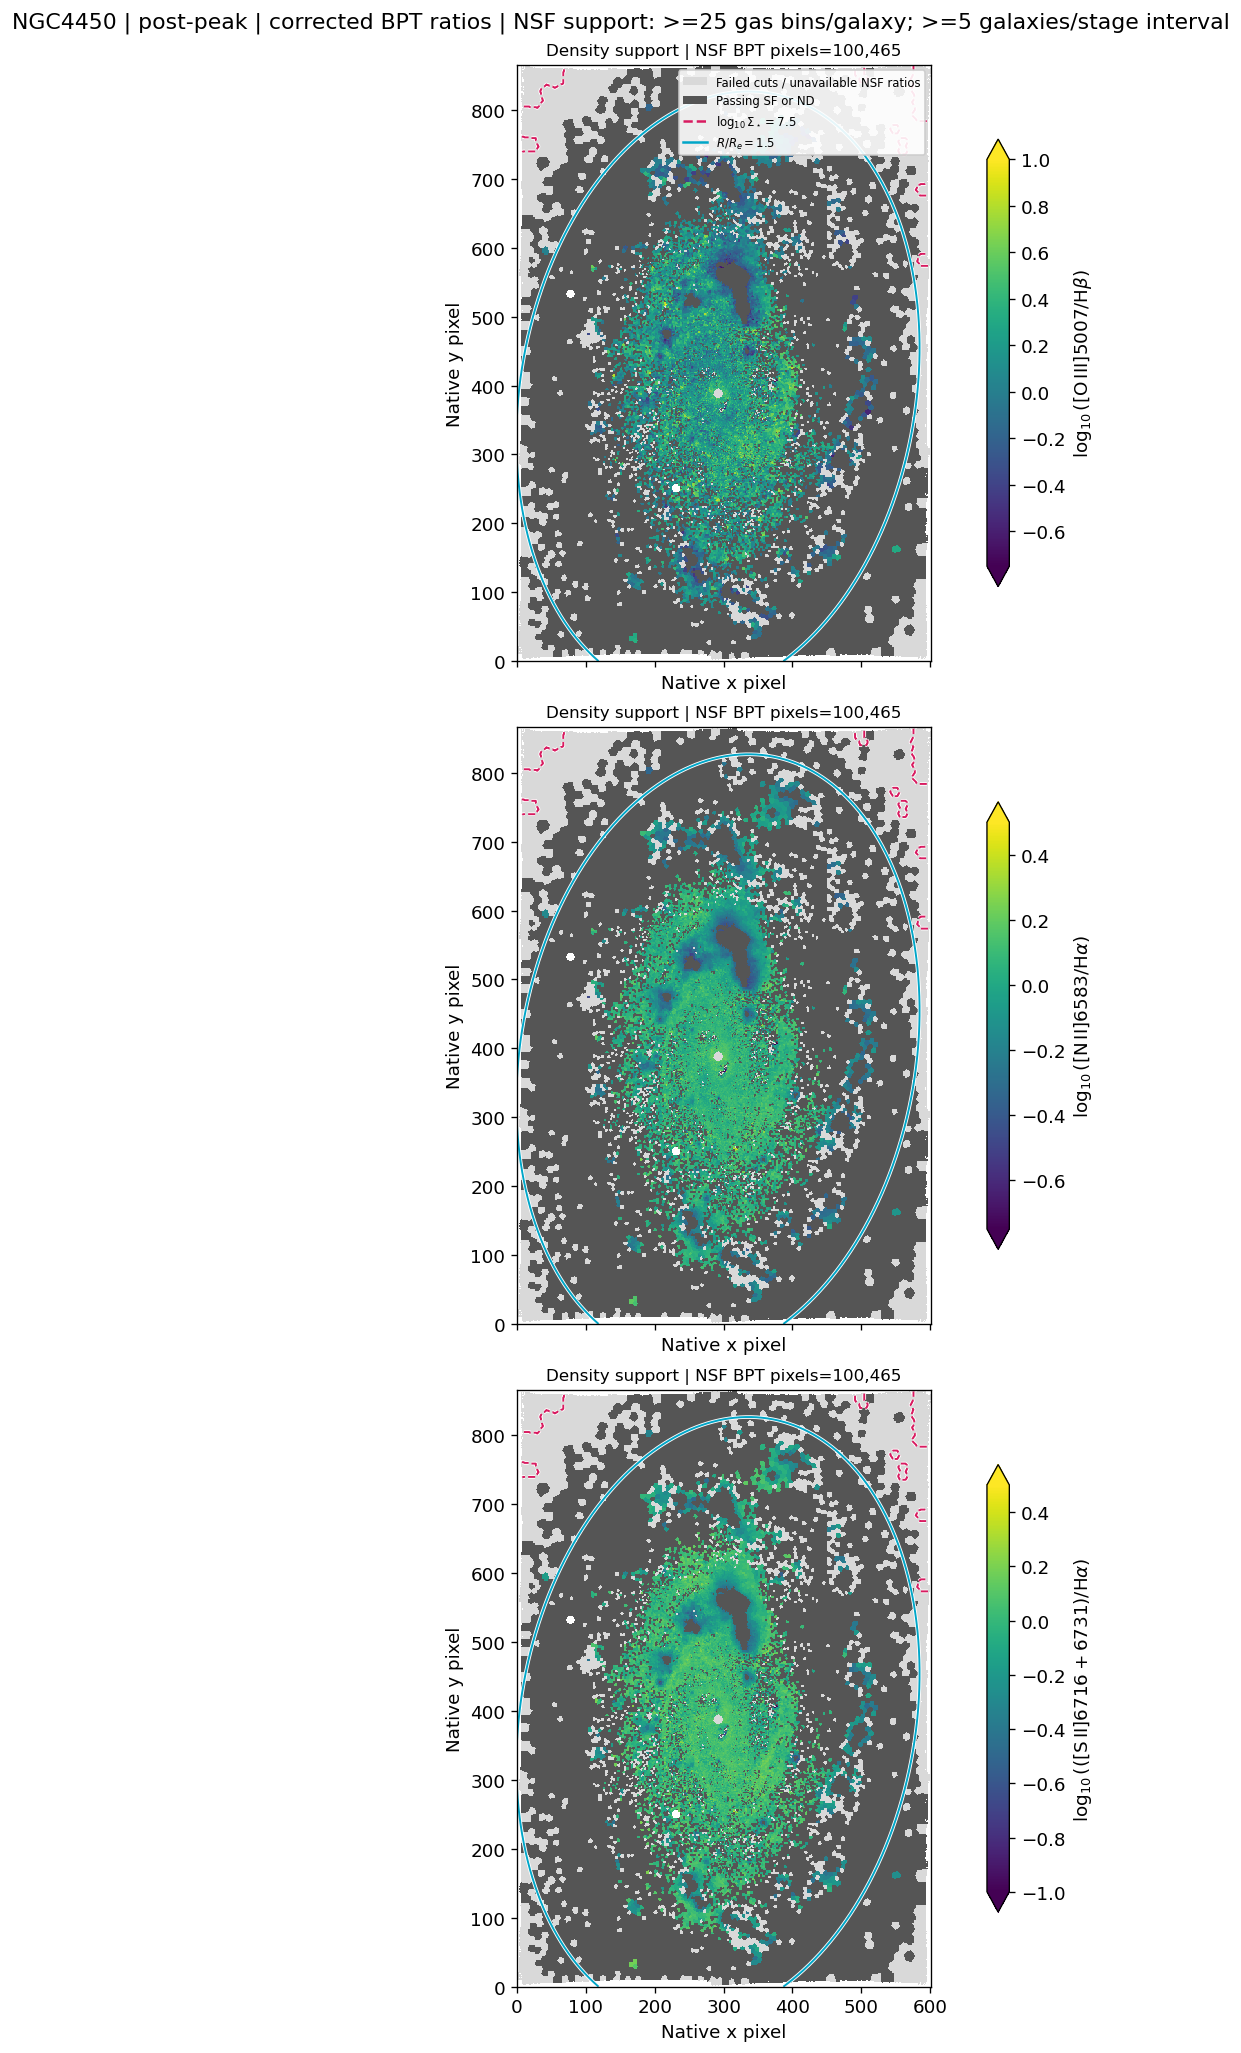

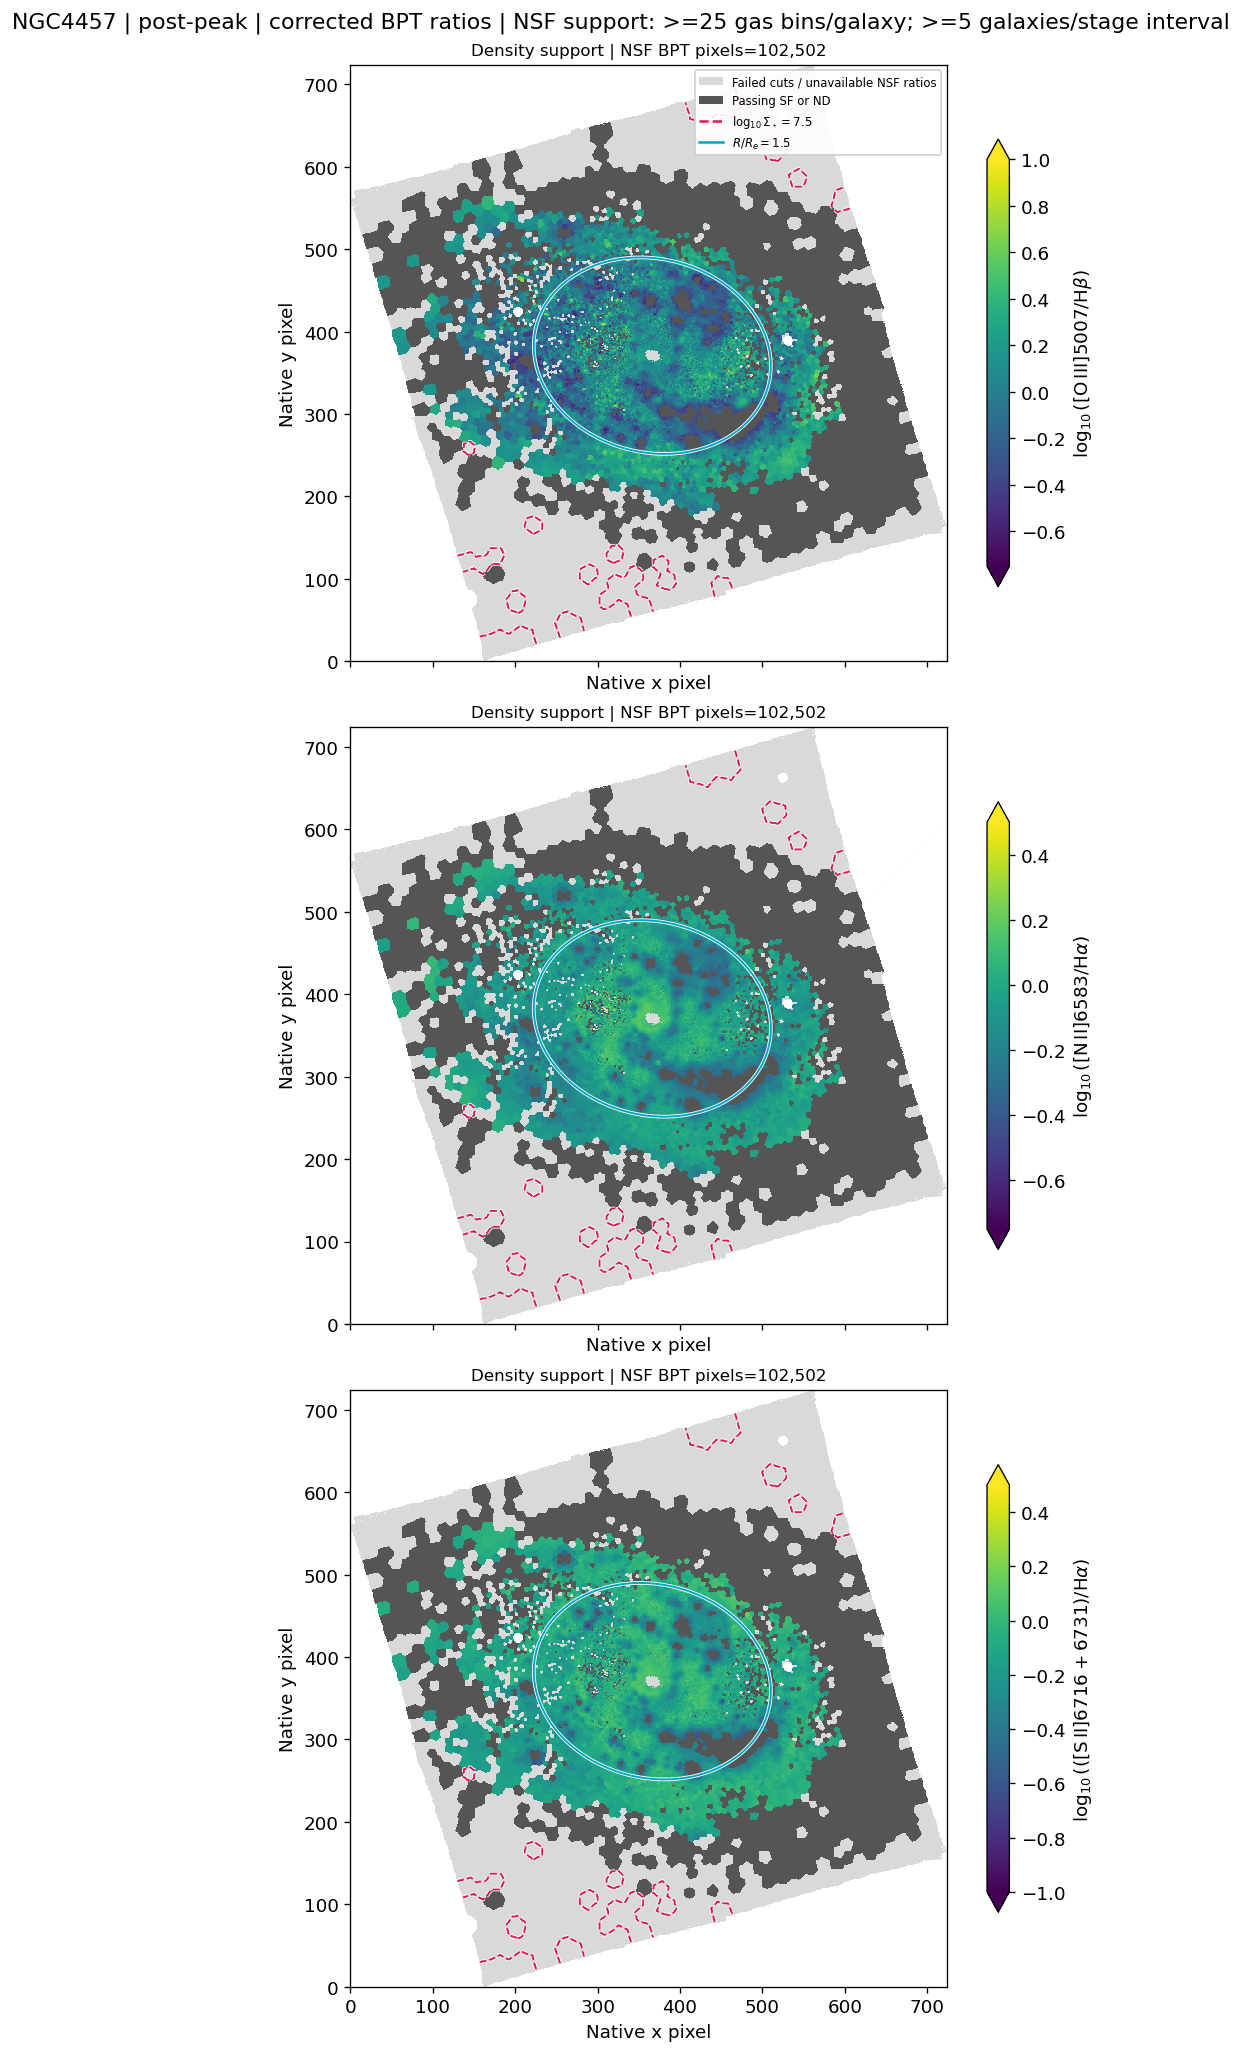

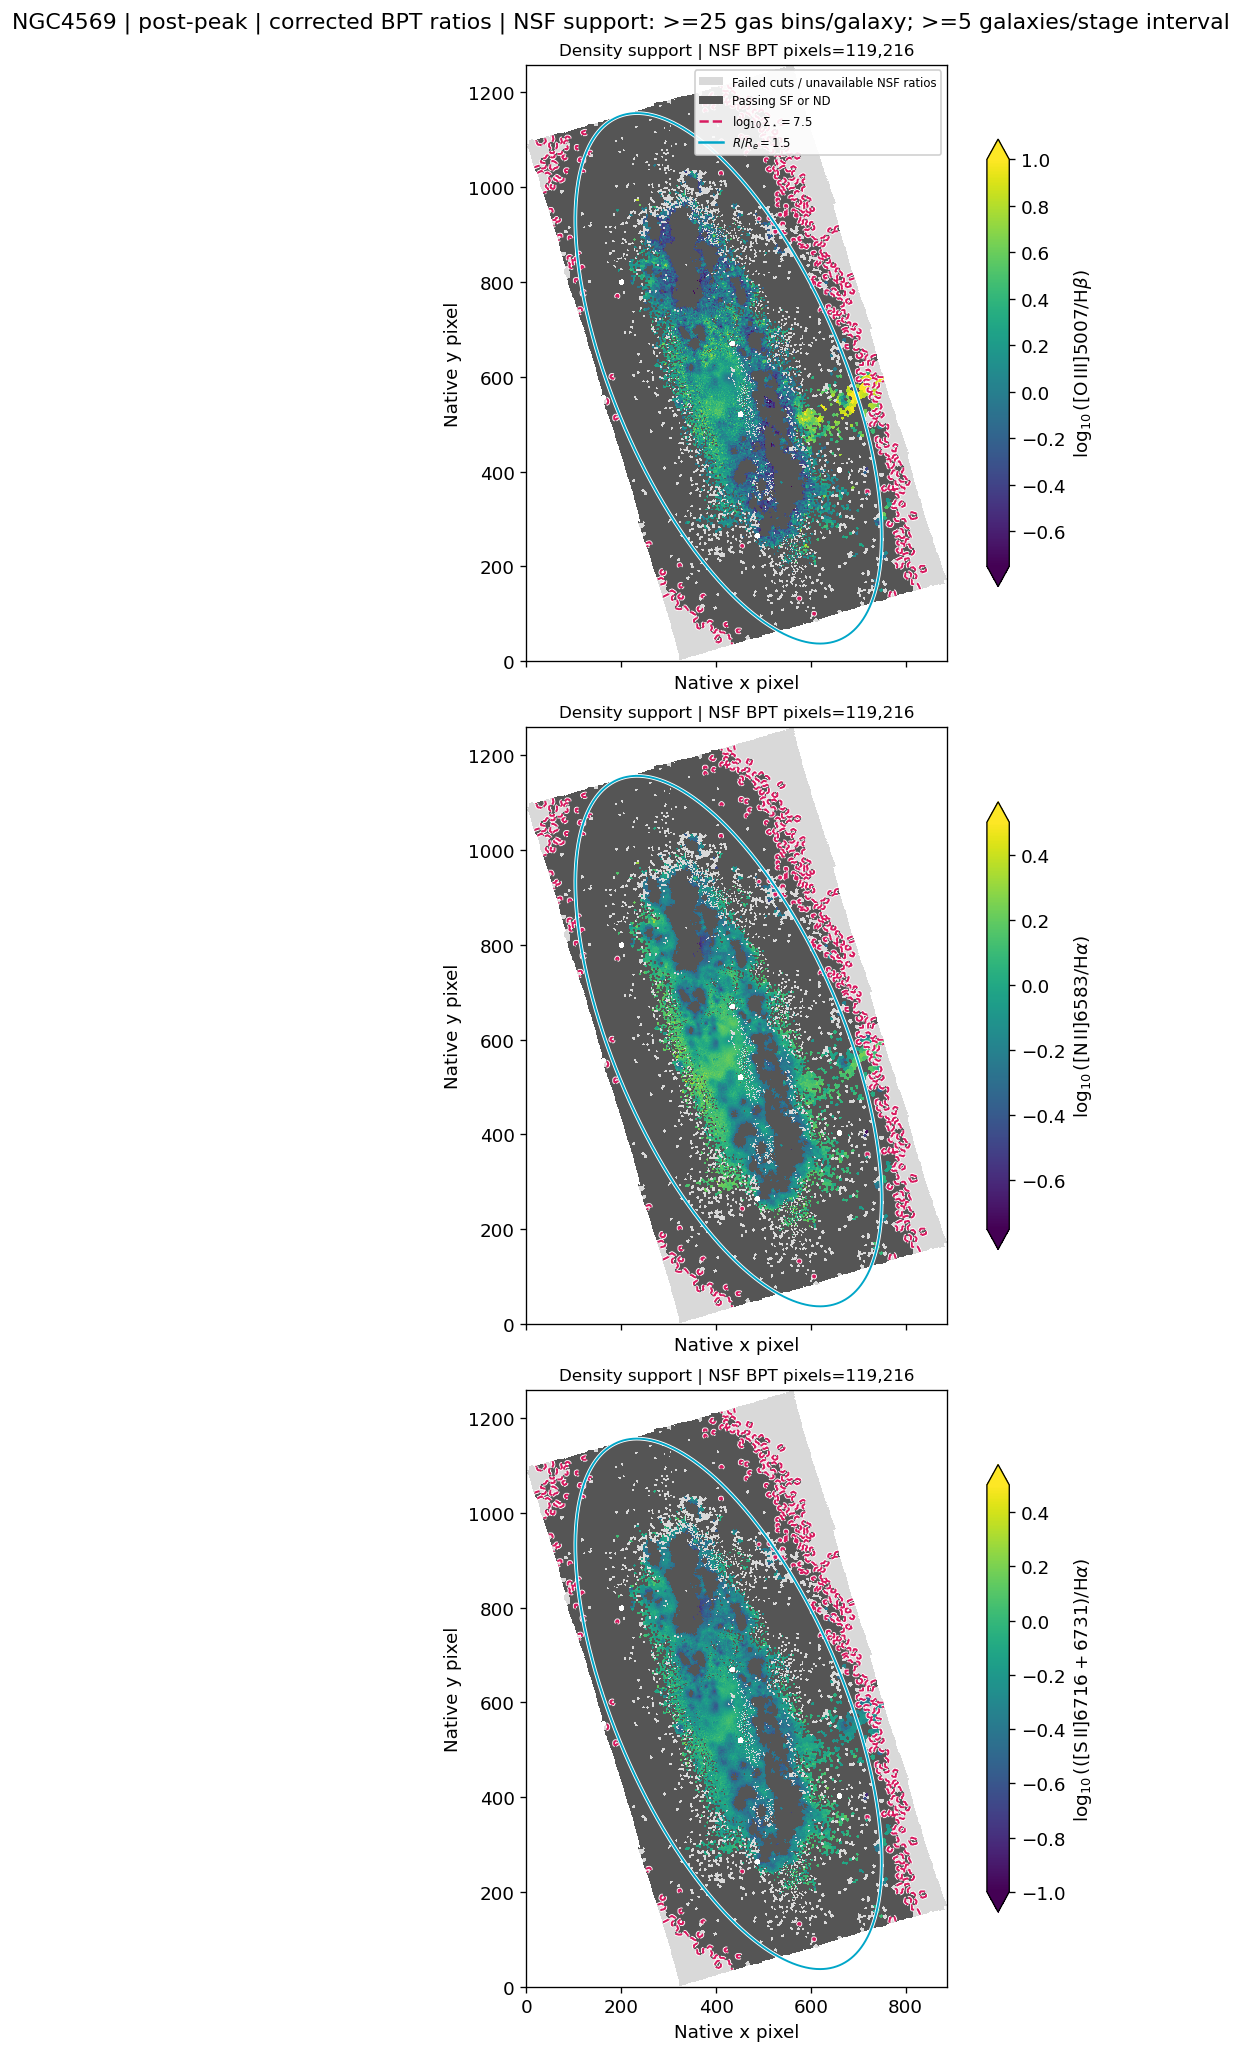

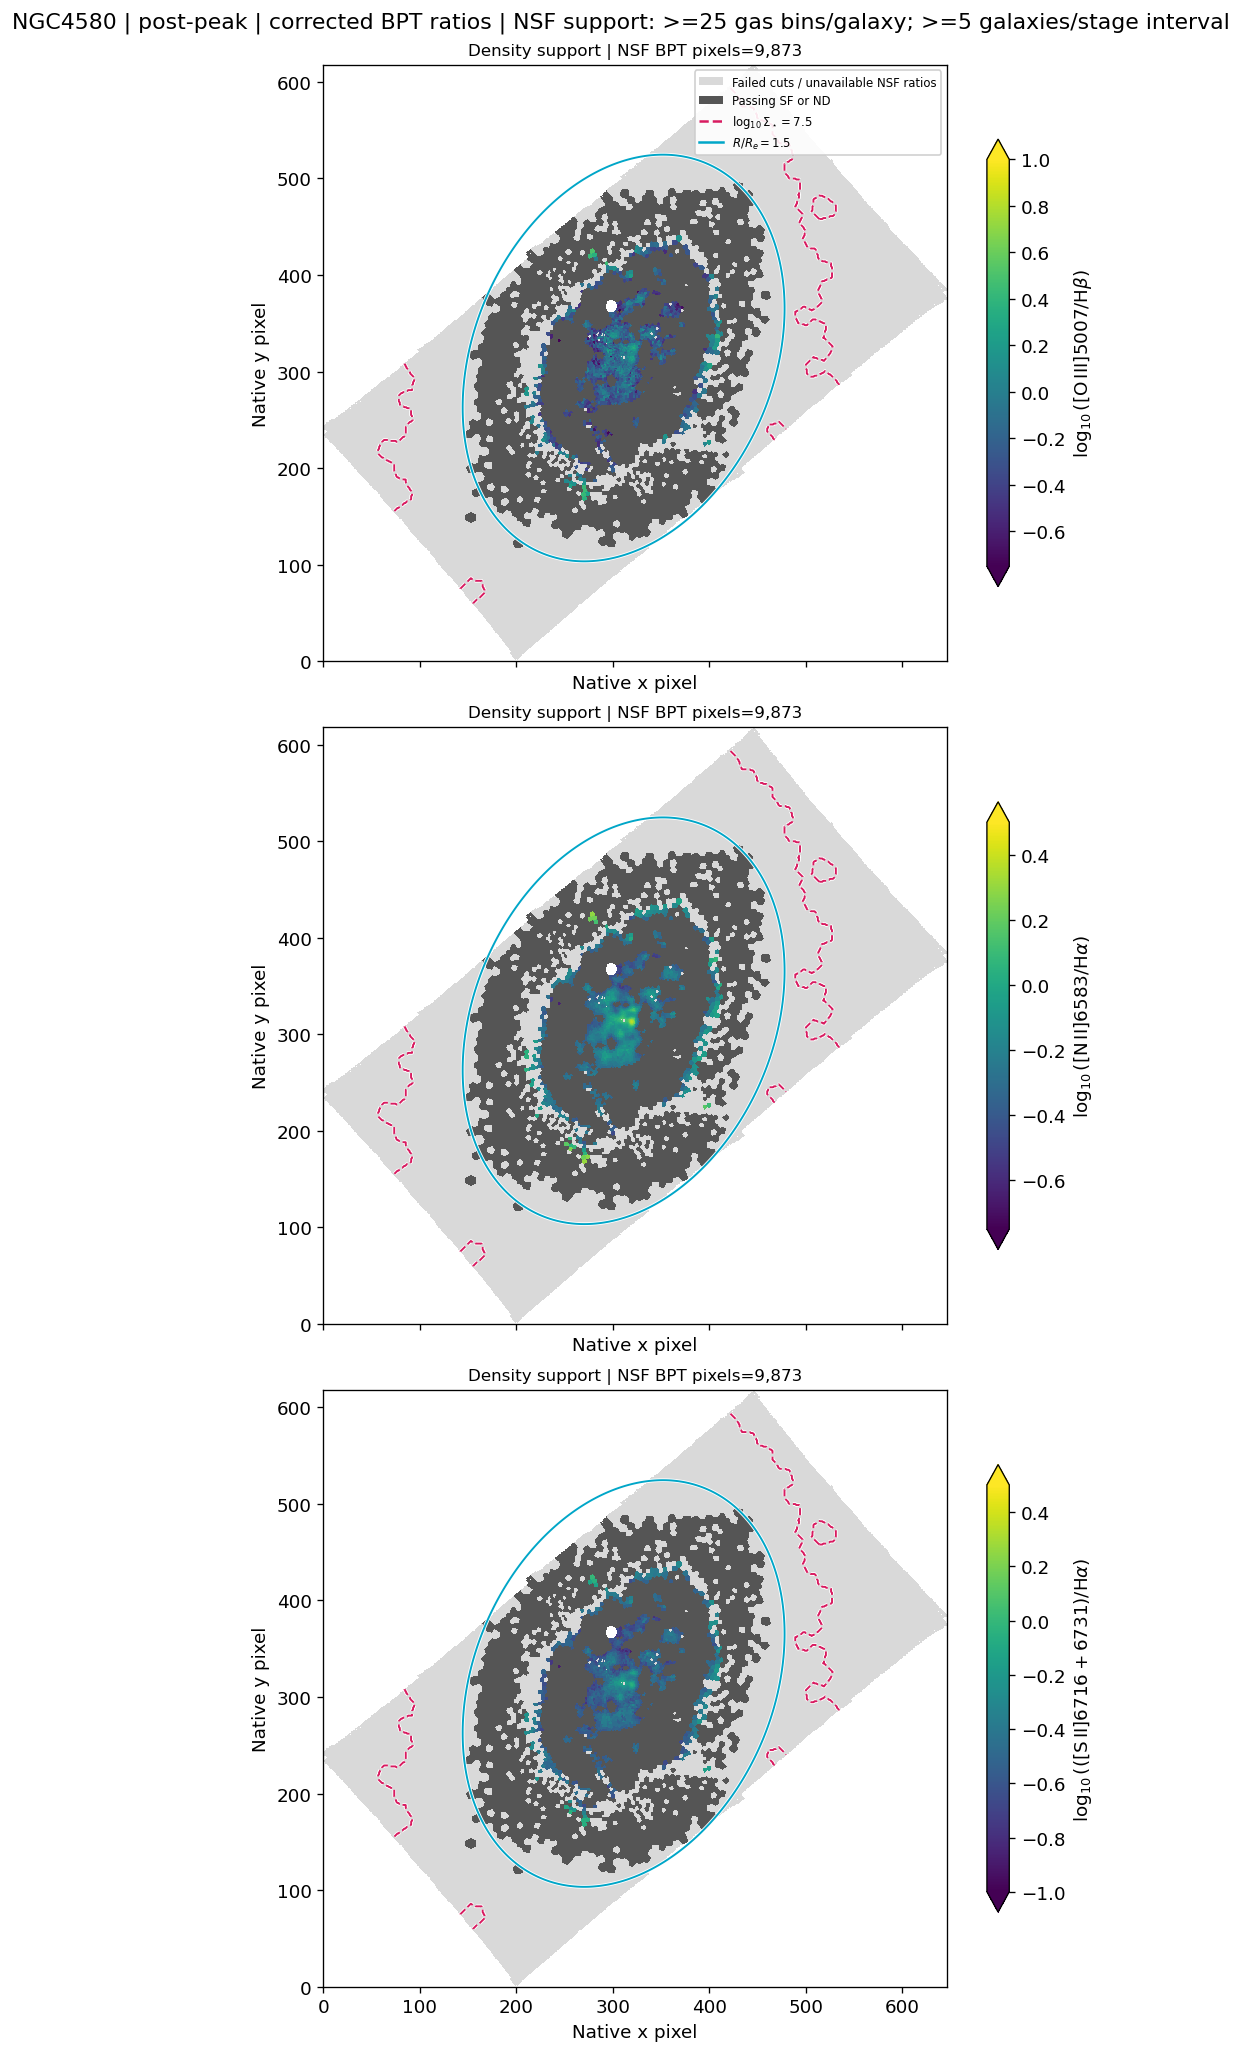

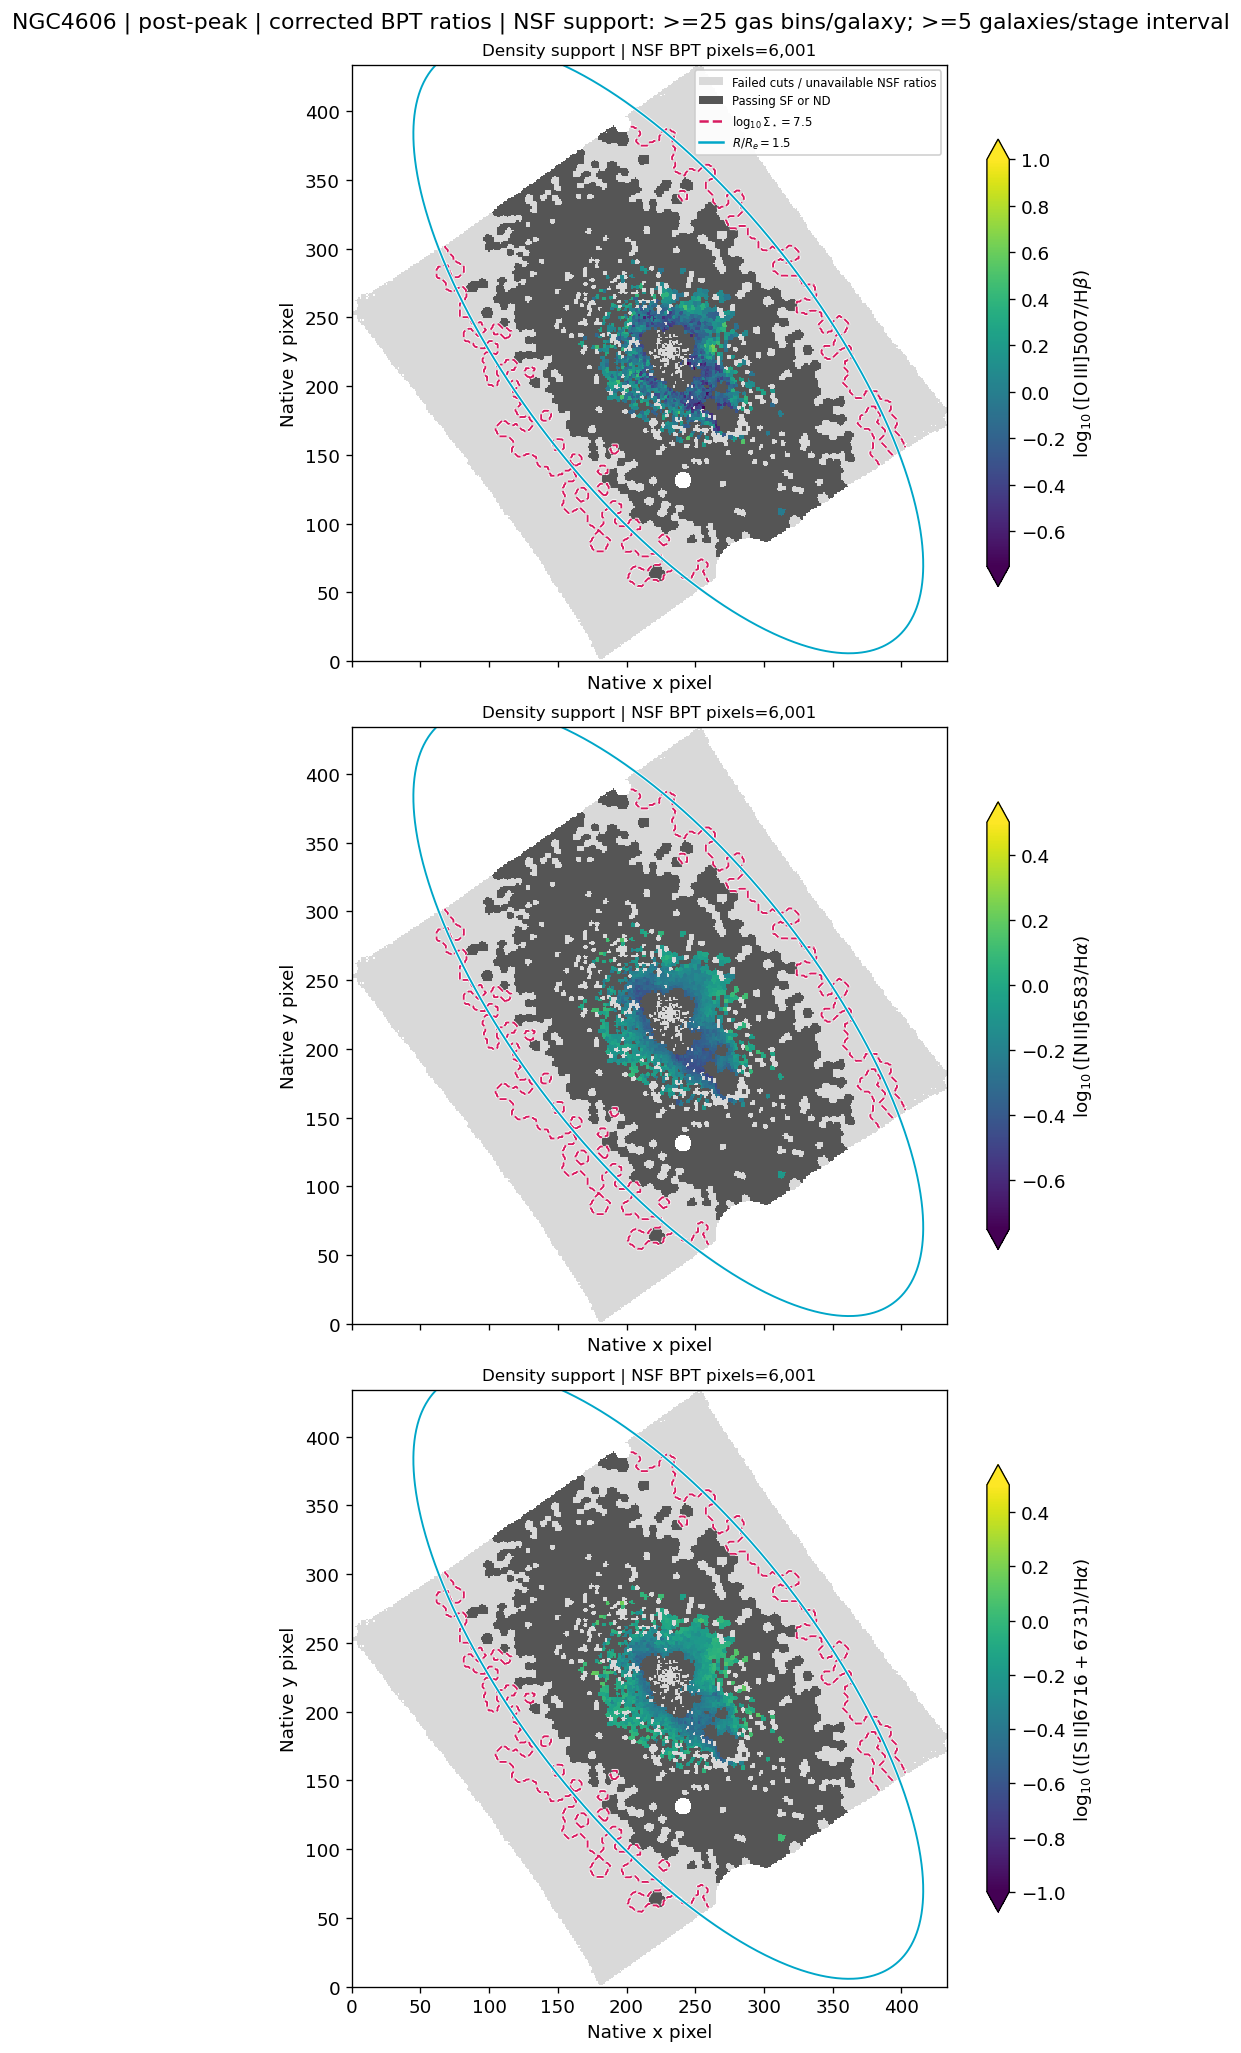

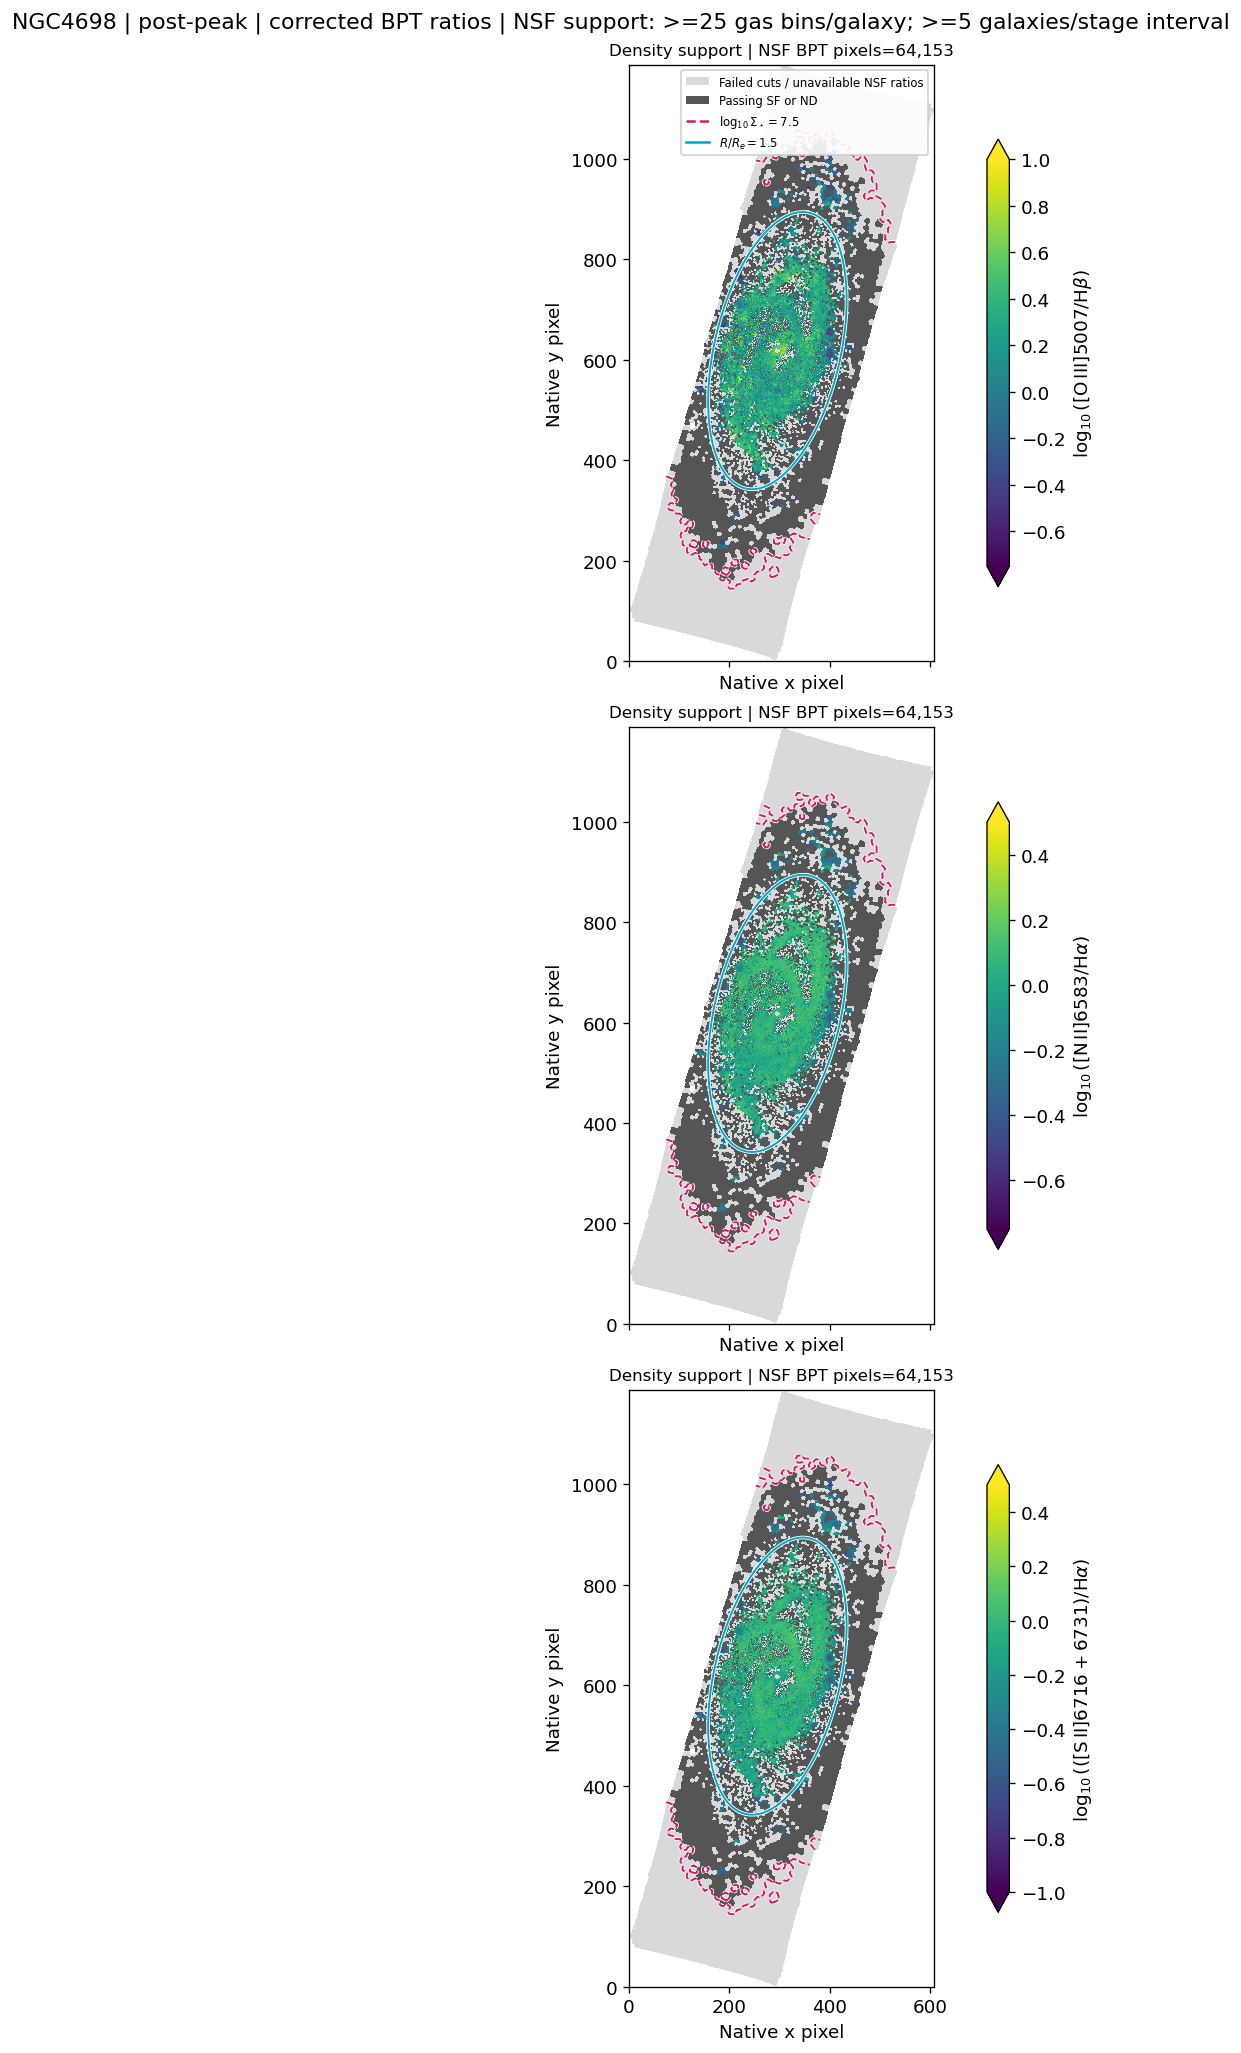

,GALID,variable,N_valid,N_failed_SNR,N_failed_counting_after_SNR,N_dark_SF_ND,N_colored_NSF,N_passing_NSF_ratios_unavailable,N_colored_density_lt7p5,N_colored_radius_gt1p5
0,IC3392,log_sigma_star,94575,37545,13181,35136,4693,4020,0,0
1,NGC4064,log_sigma_star,179882,51476,21157,74032,24615,8602,0,0
2,NGC4293,log_sigma_star,261523,7726,32357,159464,35383,26593,0,0
3,NGC4380,log_sigma_star,502065,268370,7253,175542,16461,34439,0,0
4,NGC4394,log_sigma_star,180654,5931,7372,123061,12366,31924,0,0
5,NGC4405,log_sigma_star,178518,99842,16028,51598,5990,5060,0,0
6,NGC4419,log_sigma_star,180692,46788,12055,59551,46415,15883,0,23955
7,NGC4450,log_sigma_star,501469,29817,36207,307431,100465,27549,0,303
8,NGC4457,log_sigma_star,338082,86865,20118,117153,102502,11444,0,55900
9,NGC4569,log_sigma_star,659174,19321,62886,420383,119216,37368,0,3150


,GALID,mass_7p5_contour_in_valid_disc,radius_1p5_contour_in_native_field
0,IC3392,True,True
1,NGC4064,True,True
2,NGC4293,True,True
3,NGC4380,True,True
4,NGC4394,True,True
5,NGC4405,True,True
6,NGC4419,True,True
7,NGC4450,True,True
8,NGC4457,True,True
9,NGC4569,True,True


In [10]:
from matplotlib.lines import Line2D
from matplotlib.patches import Patch
from matplotlib.colors import ListedColormap
import matplotlib.patheffects as pe

spatial_count_rows,contour_rows = [],[]
POSTPEAK_MAP_GALAXIES = []
SPATIAL_MASK_CHECKS = []
def draw_threshold_contour(ax,values,level,color,style):
    good = np.isfinite(values)
    present = bool(good.any() and np.min(values[good]) < level < np.max(values[good]))
    if present:
        contour = ax.contour(np.ma.masked_invalid(values),levels=[level],colors=[color],linestyles=[style],linewidths=1.15)
        contour.set_path_effects([pe.Stroke(linewidth=2.2,foreground="white"),pe.Normal()])
    return present

for row in POSTPEAK_SAMPLE.itertuples(index=False):
    maps = load_ratio_maps(row,geometry)
    valid = maps["valid_disc_mask"]
    keep = valid & np.isfinite(maps["snr_postfit"]) & (maps["snr_postfit"] > SFH_SNR_POSTFIT_MIN)
    density,radius = maps["log_sigma_star"],maps["radius_re"]
    
    sf_nd = maps["sf_mask"] | maps["nd_mask"]
    fig,axes = plt.subplots(3,1,figsize=(8,17),squeeze=False,sharex=True,sharey=True,layout="constrained")
    yy,xx = np.where(valid)
    for ci,variable in enumerate(("log_sigma_star",)):
        ax=axes[0,ci]
        ref = NSF_SUPPORT_BY_GALAXY_BIN.loc[NSF_SUPPORT_BY_GALAXY_BIN.GALID.eq(row.GALID)
            & NSF_SUPPORT_BY_GALAXY_BIN.variable.eq(variable)]
        footprint = np.zeros(valid.shape,dtype=bool)
        for r in ref.itertuples(index=False):
            if r.NSF_eligible_galaxy and r.eligible_stage:
                footprint |= (maps[variable] >= r.bin_left) & (maps[variable] < r.bin_left +
                    SIGMA_BIN_WIDTH)
        footprint &= keep
        colored = footprint & maps["nsf_mask"] & maps["common_bpt"]
        dark = footprint & sf_nd
        failed = valid & ~footprint
        background = np.full(valid.shape,np.nan)
        background[valid] = 0
        background[dark] = 1
        for ri,ratio in enumerate(RATIO_ORDER):
            ax=axes[ri,ci]
            ax.imshow(np.ma.masked_invalid(background),origin="lower",cmap=ListedColormap(["#d9d9d9","#555555"]),vmin=0,vmax=1,interpolation="nearest")
            im=ax.imshow(np.ma.masked_where(~colored,maps["ratio_maps"][ratio]),origin="lower",cmap="viridis",vmin=RATIO_YLIMS[ratio][0],vmax=RATIO_YLIMS[ratio][1],interpolation="nearest")
            mass_present=draw_threshold_contour(ax,np.where(valid,density,np.nan),7.5,"#d81b60","--")
            radius_present=draw_threshold_contour(ax,np.where(np.isfinite(radius),radius,np.nan),1.5,"#00a6c8","-")
            ax.set_xlim(max(0,xx.min()-5),min(valid.shape[1]-1,xx.max()+5));ax.set_ylim(max(0,yy.min()-5),min(valid.shape[0]-1,yy.max()+5))
            ax.set_title("Density support"+f" | NSF BPT pixels={colored.sum():,}",fontsize=10)
            ax.set_xlabel("Native x pixel");ax.set_ylabel("Native y pixel");ax.set_aspect("equal")
            fig.colorbar(im,ax=axes[ri,:],shrink=.75,extend="both",label=RATIO_LABELS[ratio])
        expected = RATIO_BY_GALAXY_BIN.loc[RATIO_BY_GALAXY_BIN.GALID.eq(row.GALID)
            & RATIO_BY_GALAXY_BIN.variable.eq(variable)&RATIO_BY_GALAXY_BIN.category.eq("NSF")
            & RATIO_BY_GALAXY_BIN.contributes&RATIO_BY_GALAXY_BIN.eligible_stage].N_ratio_pixels.sum()
        SPATIAL_MASK_CHECKS.append(bool(colored.sum() == expected
            and not np.any(colored & (~keep | sf_nd))
            and not np.any(dark & (~keep | maps["nsf_mask"]))
            and not np.any((colored | dark) & failed)))
        spatial_count_rows.append({"GALID":row.GALID,"variable":variable,
            "N_valid":int(valid.sum()),"N_failed_SNR":int((valid & ~keep).sum()),
            "N_failed_counting_after_SNR":int((keep & ~footprint).sum()),
            "N_dark_SF_ND":int(dark.sum()),"N_colored_NSF":int(colored.sum()),
            "N_passing_NSF_ratios_unavailable":int((footprint & maps["nsf_mask"] & ~maps["common_bpt"]).sum()),
            "N_colored_density_lt7p5":int((colored & (density < 7.5)).sum()),
            "N_colored_radius_gt1p5":int((colored & (radius > 1.5)).sum())})
    contour_rows.append({"GALID":row.GALID,"mass_7p5_contour_in_valid_disc":mass_present,
        "radius_1p5_contour_in_native_field":radius_present})
    axes[0,0].legend(handles=[
        Patch(facecolor="#d9d9d9",label="Failed cuts / unavailable NSF ratios"),
        Patch(facecolor="#555555",label="Passing SF or ND"),
        Line2D([],[],color="#d81b60",ls="--",label=r"$\log_{10}\Sigma_\star=7.5$"),
        Line2D([],[],color="#00a6c8",label=r"$R/R_e=1.5$")],loc="upper right",fontsize=7,framealpha=.9)
    fig.suptitle(row.GALID+" | post-peak | corrected BPT ratios | NSF support: >=25 gas bins/galaxy; >=5 galaxies/stage interval")
    POSTPEAK_MAP_GALAXIES.append(row.GALID)
    plt.show()
    del maps
POSTPEAK_SPATIAL_COUNTS = pd.DataFrame(spatial_count_rows)
POSTPEAK_CONTOUR_QC = pd.DataFrame(contour_rows)
display(POSTPEAK_SPATIAL_COUNTS)
display(POSTPEAK_CONTOUR_QC)


## Validation and support limits

Actual ratio contributors can be fewer than five; the stage eligibility gate is counted from NSF alone. Bootstrap bands omit flux, dust and geometry systematics. Common-line detection selects a brighter subset and missing ratios do not establish missing emission.

In [11]:
checks={
    "one_density_support_footprint_per_galaxy":bool(POSTPEAK_SPATIAL_COUNTS.groupby("GALID").size().eq(1).all()
        and POSTPEAK_SPATIAL_COUNTS.variable.eq("log_sigma_star").all()),
    "median_estimator_labels":all("median" in label for label in BRANCH_LABELS.values()),
    "four_categories":set(RATIO_BY_GALAXY_BIN.category)==set(CATEGORY_ORDER),
    "all_spatial_counts_match_ratio_profiles":all(SPATIAL_MASK_CHECKS),
    "complete_pixel_partition":bool(POSTPEAK_SPATIAL_COUNTS.N_valid.eq(POSTPEAK_SPATIAL_COUNTS[["N_failed_SNR","N_failed_counting_after_SNR","N_dark_SF_ND","N_colored_NSF","N_passing_NSF_ratios_unavailable"]].sum(axis=1)).all()),
    "all_postpeak_galaxies_mapped":set(POSTPEAK_MAP_GALAXIES)==set(POSTPEAK_SAMPLE.GALID),
}
for branch,t in RATIO_TABLES.items():
    checks[branch+"_NSF_gate"]=bool(t.eligible_stage.equals(t.N_NSF_gal_support.ge(5)))
    checks[branch+"_rejected_estimates_nan"]=bool(t.loc[~t.eligible_stage,["value","value_lo","value_hi"]].isna().all().all())
    checks[branch+"_intervals_ordered"]=bool(t.dropna(subset=["value_lo","value_hi"]).value_lo.le(t.dropna(subset=["value_lo","value_hi"]).value_hi).all())
    checks[branch+"_actual_contributors_below_NSF"]=bool(t.N_gal_support.le(t.N_NSF_gal_support).all())
display(pd.Series(checks,name="passed"));assert all(checks.values()),checks
print("BPT_RATIO_NOTEBOOK_VALIDATION_OK")


one_density_support_footprint_per_galaxy    True
median_estimator_labels                     True
four_categories                             True
all_spatial_counts_match_ratio_profiles     True
complete_pixel_partition                    True
all_postpeak_galaxies_mapped                True
equal_NSF_gate                              True
equal_rejected_estimates_nan                True
equal_intervals_ordered                     True
equal_actual_contributors_below_NSF         True
pooled_NSF_gate                             True
pooled_rejected_estimates_nan               True
pooled_intervals_ordered                    True
pooled_actual_contributors_below_NSF        True
Name: passed, dtype: bool

BPT_RATIO_NOTEBOOK_VALIDATION_OK
